# Acquisition des données

In [52]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:


def get_historical_weather_data(latitude, longitude, start_date, end_date):
    """
    Récupérer les données météorologiques historiques via l'API Open-Meteo
    
    Args:
        latitude (float): Latitude de la ville
        longitude (float): Longitude de la ville
        start_date (str): Date de début (format: YYYY-MM-DD)
        end_date (str): Date de fin (format: YYYY-MM-DD)
        
    Returns:
        pandas.DataFrame: DataFrame contenant les données de température
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m",
        "timezone": "auto"
    }
    
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        
        # Création du DataFrame
        df = pd.DataFrame({
            "time": data["hourly"]["time"],
            "temperature_2m": data["hourly"]["temperature_2m"]
        })
        
        # Conversion de la colonne time en datetime
        df["time"] = pd.to_datetime(df["time"])
        
        # Vérification des valeurs manquantes
        if df["temperature_2m"].isna().sum() > 0:
            print(f"Valeurs manquantes détectées: {df['temperature_2m'].isna().sum()}")
            # Interpolation linéaire pour les valeurs manquantes
            df["temperature_2m"] = df["temperature_2m"].interpolate(method="linear")
            
        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        print(response.text)
        return None



In [4]:
# Exemple d'utilisation
if __name__ == "__main__":
    # Coordonnées de Paris
    latitude = 48.8566
    longitude = 2.3522
    
    # Période d'un an
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")
    
    df = get_historical_weather_data(latitude, longitude, start_date, end_date)
    
    if df is not None:
        print(f"Données récupérées: {len(df)} entrées")
        print(df.head())
        
        # Sauvegarde des données brutes
        df.to_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/raw_weather_data.csv", index=False)

Valeurs manquantes détectées: 45
Données récupérées: 8784 entrées
                 time  temperature_2m
0 2024-04-03 00:00:00            11.6
1 2024-04-03 01:00:00            11.2
2 2024-04-03 02:00:00            10.6
3 2024-04-03 03:00:00            10.4
4 2024-04-03 04:00:00            10.2


# Transformation de la série temporelle

In [6]:

import matplotlib.pyplot as plt


def transform_to_3h_interval(df):
    """
    Transformer les données horaires en données avec un pas de temps de 3 heures
    
    Args:
        df (pandas.DataFrame): DataFrame avec données horaires
        
    Returns:
        pandas.DataFrame: DataFrame avec données agrégées par tranches de 3 heures
    """
    # Copie du DataFrame
    df_copy = df.copy()
    
    # Création d'une colonne pour grouper par tranches de 3 heures
    df_copy['hour'] = df_copy['time'].dt.hour
    df_copy['group_3h'] = (df_copy['hour'] // 3) * 3
    
    # Création d'une colonne de date sans l'heure
    df_copy['date'] = df_copy['time'].dt.date
    
    # Création d'un nouveau DataFrame pour stocker les résultats
    result = []
    
    # Pour chaque jour et chaque groupe de 3 heures
    for date, date_group in df_copy.groupby('date'):
        for group_3h, hour_group in date_group.groupby('group_3h'):
            # Calcul de la moyenne de température
            avg_temp = hour_group['temperature_2m'].mean()
            
            # Création d'un timestamp pour cette période de 3 heures
            timestamp = datetime.combine(date, datetime.min.time()) + pd.Timedelta(hours=group_3h)
            
            result.append({
                'time': timestamp,
                'temperature_2m': round(avg_temp, 1)
            })
    
    # Création du DataFrame final
    df_3h = pd.DataFrame(result)
    
    # Tri par date/heure
    df_3h = df_3h.sort_values('time')
    
    return df_3h


Données transformées: 2928 entrées
                 time  temperature_2m
0 2024-04-03 00:00:00            11.1
1 2024-04-03 03:00:00            10.2
2 2024-04-03 06:00:00            10.1
3 2024-04-03 09:00:00            11.9
4 2024-04-03 12:00:00            15.3


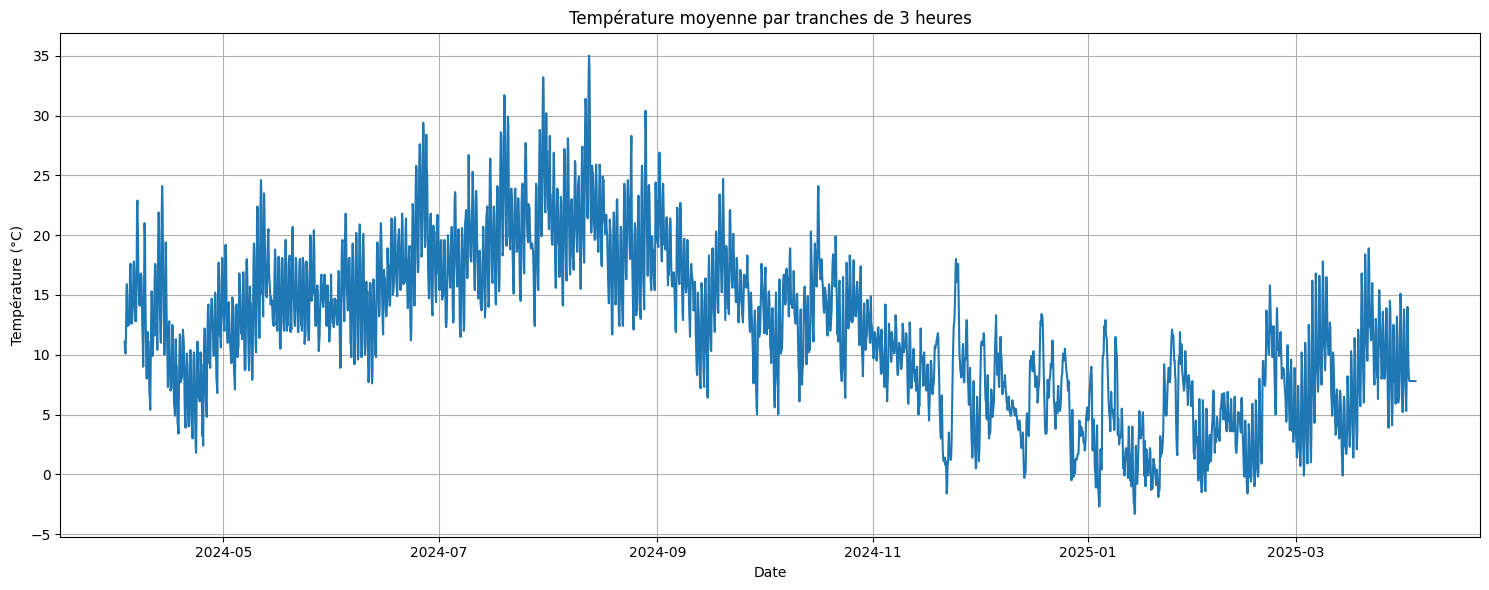

In [ ]:

if __name__ == "__main__":
    # Chargement des données brutes
    df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/raw_weather_data.csv")
    df['time'] = pd.to_datetime(df['time'])
    
    # Transformation en données avec un pas de 3 heures
    df_3h = transform_to_3h_interval(df)
    
    print(f"Données transformées: {len(df_3h)} entrées")
    print(df_3h.head())
    
    # Visualisation des données
    plt.figure(figsize=(15, 6))
    plt.plot(df_3h['time'], df_3h['temperature_2m'])
    plt.title('Température moyenne par tranches de 3 heures')
    plt.xlabel('Date')
    plt.ylabel('Température (°C)')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('temperature_3h.png')
    
    # Sauvegarde des données transformées
    df_3h.to_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/weather_data_3h.csv", index=False)

# Analyse exploratoire

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

In [11]:


def exploratory_analysis(df):
    """
    Réaliser une analyse exploratoire des données de température
    
    Args:
        df (pandas.DataFrame): DataFrame avec les données de température
    """
    # Configuration du style des graphiques
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # 1. Visualisation de la série temporelle
    plt.figure(figsize=(15, 6))
    plt.plot(df['time'], df['temperature_2m'])
    plt.title('Série temporelle de température (pas de 3 heures)')
    plt.xlabel('Date')
    plt.ylabel('Température (°C)')
    plt.tight_layout()
    plt.savefig('time_series_plot.png')
    
    # 2. Analyse statistique descriptive
    print("Statistiques descriptives:")
    print(df['temperature_2m'].describe())
    
    # 3. Distribution des températures
    plt.figure(figsize=(10, 6))
    sns.histplot(df['temperature_2m'], kde=True)
    plt.title('Distribution des températures')
    plt.xlabel('Température (°C)')
    plt.ylabel('Fréquence')
    plt.tight_layout()
    plt.savefig('temperature_distribution.png')
    
    # 4. Box plot par mois pour observer les variations saisonnières
    df['month'] = df['time'].dt.month
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='month', y='temperature_2m', data=df)
    plt.title('Variations de température par mois')
    plt.xlabel('Mois')
    plt.ylabel('Température (°C)')
    plt.tight_layout()
    plt.savefig('monthly_boxplots.png')
    
    # 5. Box plot par heure pour observer les variations journalières
    df['hour'] = df['time'].dt.hour
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='hour', y='temperature_2m', data=df.loc[df['hour'].isin([0, 3, 6, 9, 12, 15, 18, 21])])
    plt.title('Variations de température par tranche horaire')
    plt.xlabel('Heure')
    plt.ylabel('Température (°C)')
    plt.tight_layout()
    plt.savefig('hourly_boxplots.png')
    
    # 6. Décomposition de la série temporelle
    # Pour la décomposition, on a besoin d'une série avec un index temporel
    ts = df.set_index('time')['temperature_2m']
    
    # Décomposition (supposant une période quotidienne de 8 points - 8 tranches de 3h)
    try:
        decomposition = seasonal_decompose(ts, period=8)
        
        fig, axes = plt.subplots(4, 1, figsize=(15, 12))
        decomposition.observed.plot(ax=axes[0])
        axes[0].set_title('Série observée')
        decomposition.trend.plot(ax=axes[1])
        axes[1].set_title('Tendance')
        decomposition.seasonal.plot(ax=axes[2])
        axes[2].set_title('Saisonnalité')
        decomposition.resid.plot(ax=axes[3])
        axes[3].set_title('Résidus')
        plt.tight_layout()
        plt.savefig('decomposition_daily.png')
        
        # Décomposition annuelle (supposant une période annuelle de 365*8 points)
        if len(ts) >= 365*8:  # Si nous avons au moins un an de données
            decomposition_yearly = seasonal_decompose(ts, period=365*8//12)  # Période mensuelle pour approximer
            
            fig, axes = plt.subplots(4, 1, figsize=(15, 12))
            decomposition_yearly.observed.plot(ax=axes[0])
            axes[0].set_title('Série observée')
            decomposition_yearly.trend.plot(ax=axes[1])
            axes[1].set_title('Tendance')
            decomposition_yearly.seasonal.plot(ax=axes[2])
            axes[2].set_title('Saisonnalité annuelle')
            decomposition_yearly.resid.plot(ax=axes[3])
            axes[3].set_title('Résidus')
            plt.tight_layout()
            plt.savefig('decomposition_yearly.png')
    except Exception as e:
        print(f"Erreur lors de la décomposition: {e}")
    
    # 7. Autocorrélation et autocorrélation partielle
    plt.figure(figsize=(15, 6))
    plot_acf(ts, lags=50, ax=plt.gca())
    plt.title('Fonction d\'autocorrélation')
    plt.tight_layout()
    plt.savefig('acf_plot.png')
    
    plt.figure(figsize=(15, 6))
    plot_pacf(ts, lags=50, ax=plt.gca())
    plt.title('Fonction d\'autocorrélation partielle')
    plt.tight_layout()
    plt.savefig('pacf_plot.png')
    
    # 8. Recherche de valeurs aberrantes
    z_scores = np.abs((df['temperature_2m'] - df['temperature_2m'].mean()) / df['temperature_2m'].std())
    outliers = df[z_scores > 3]
    print(f"Nombre de valeurs aberrantes potentielles (z-score > 3): {len(outliers)}")
    
    if len(outliers) > 0:
        plt.figure(figsize=(15, 6))
        plt.scatter(df['time'], df['temperature_2m'], alpha=0.5, label='Données normales')
        plt.scatter(outliers['time'], outliers['temperature_2m'], color='red', label='Valeurs aberrantes potentielles')
        plt.title('Identification des valeurs aberrantes potentielles')
        plt.xlabel('Date')
        plt.ylabel('Température (°C)')
        plt.legend()
        plt.tight_layout()
        plt.savefig('outliers.png')


Statistiques descriptives:
count    2928.000000
mean       12.119570
std         6.618892
min        -3.300000
25%         7.300000
50%        12.100000
75%        16.700000
max        35.000000
Name: temperature_2m, dtype: float64
Nombre de valeurs aberrantes potentielles (z-score > 3): 5


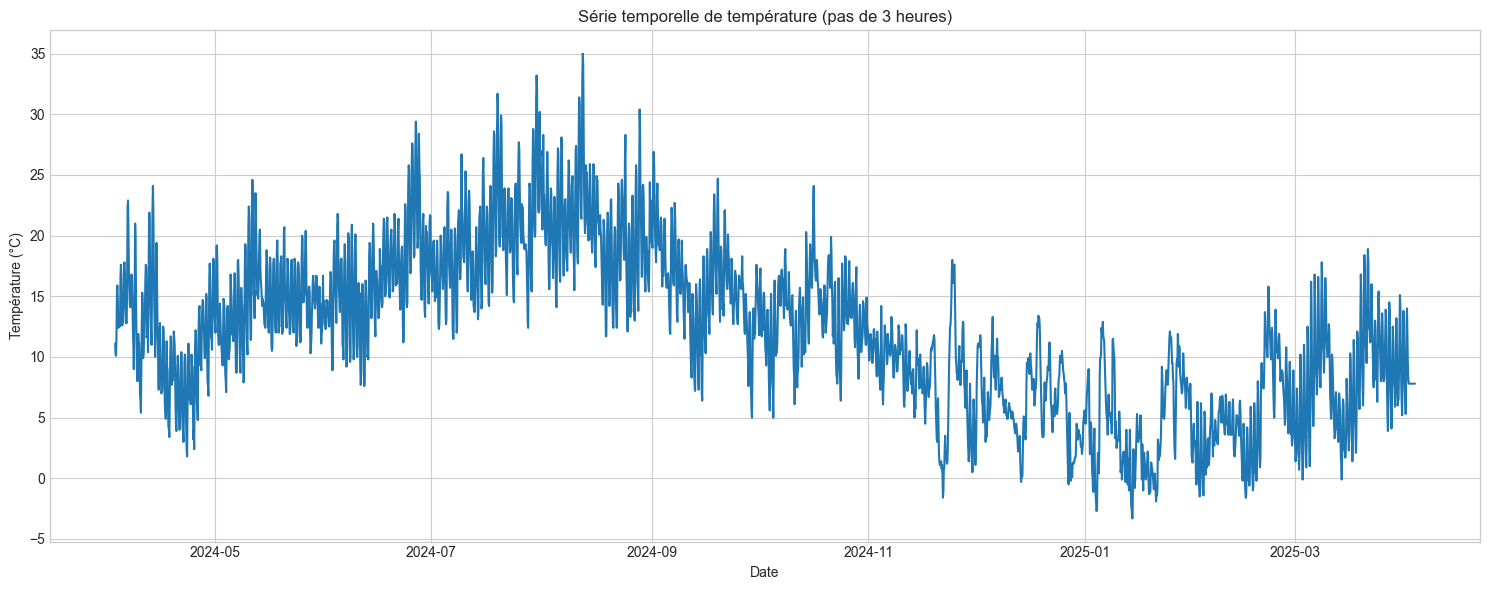

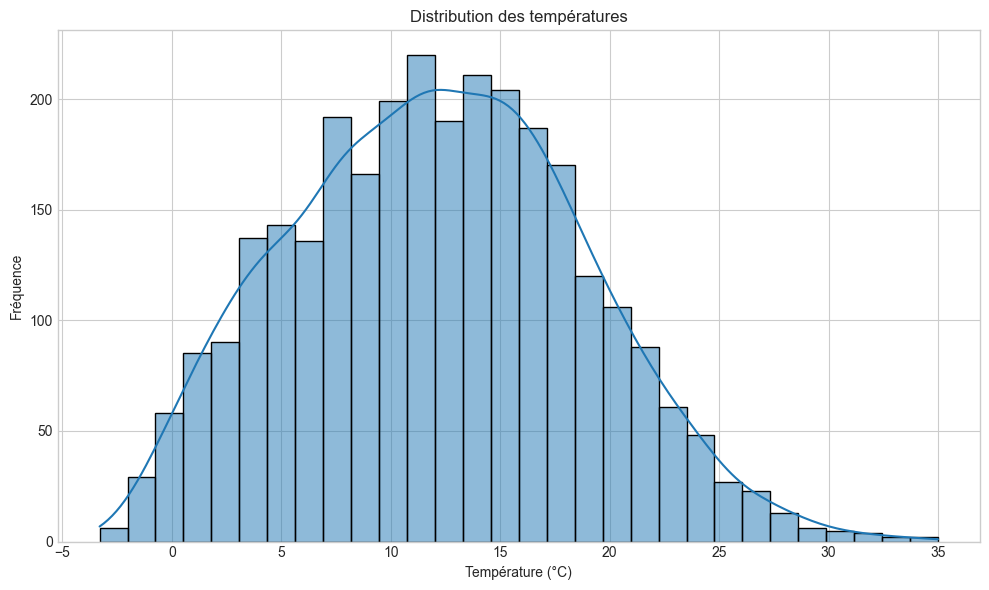

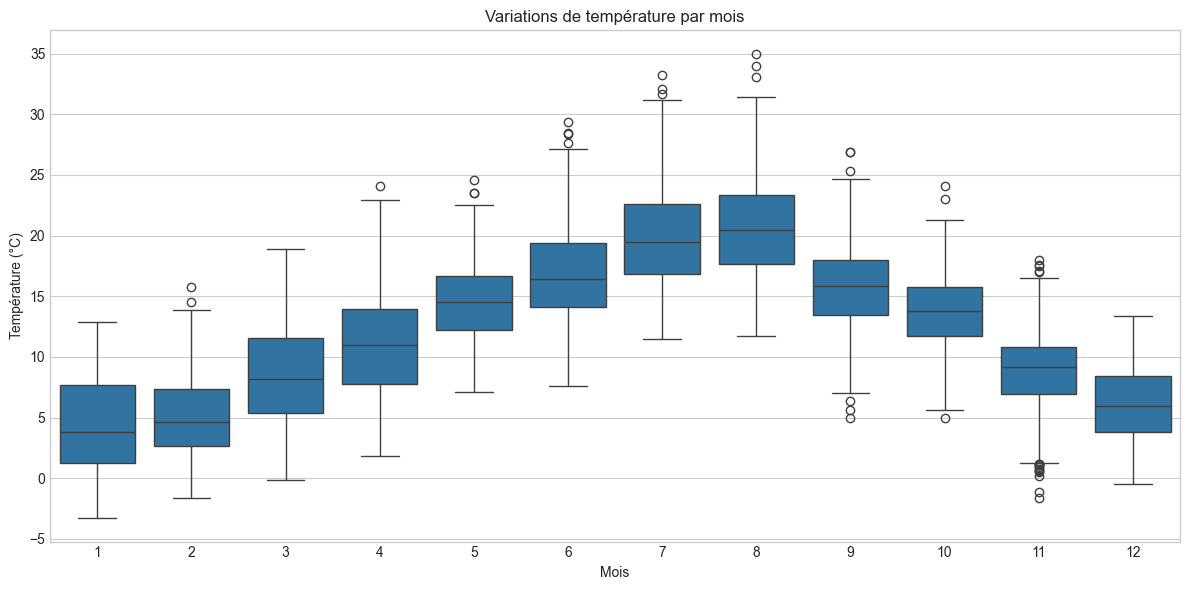

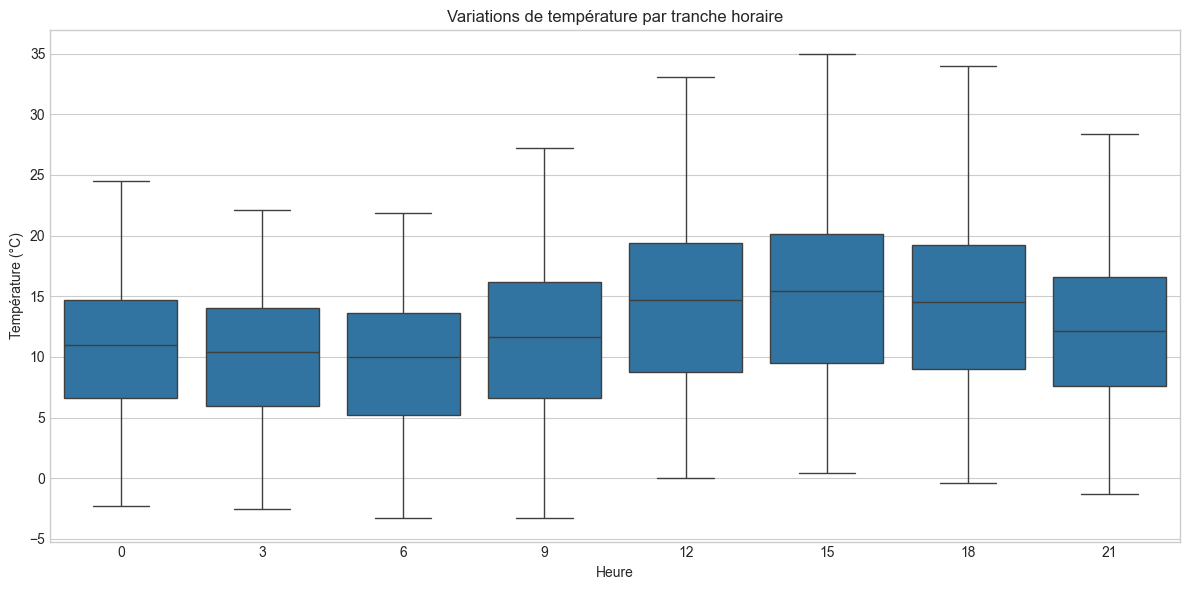

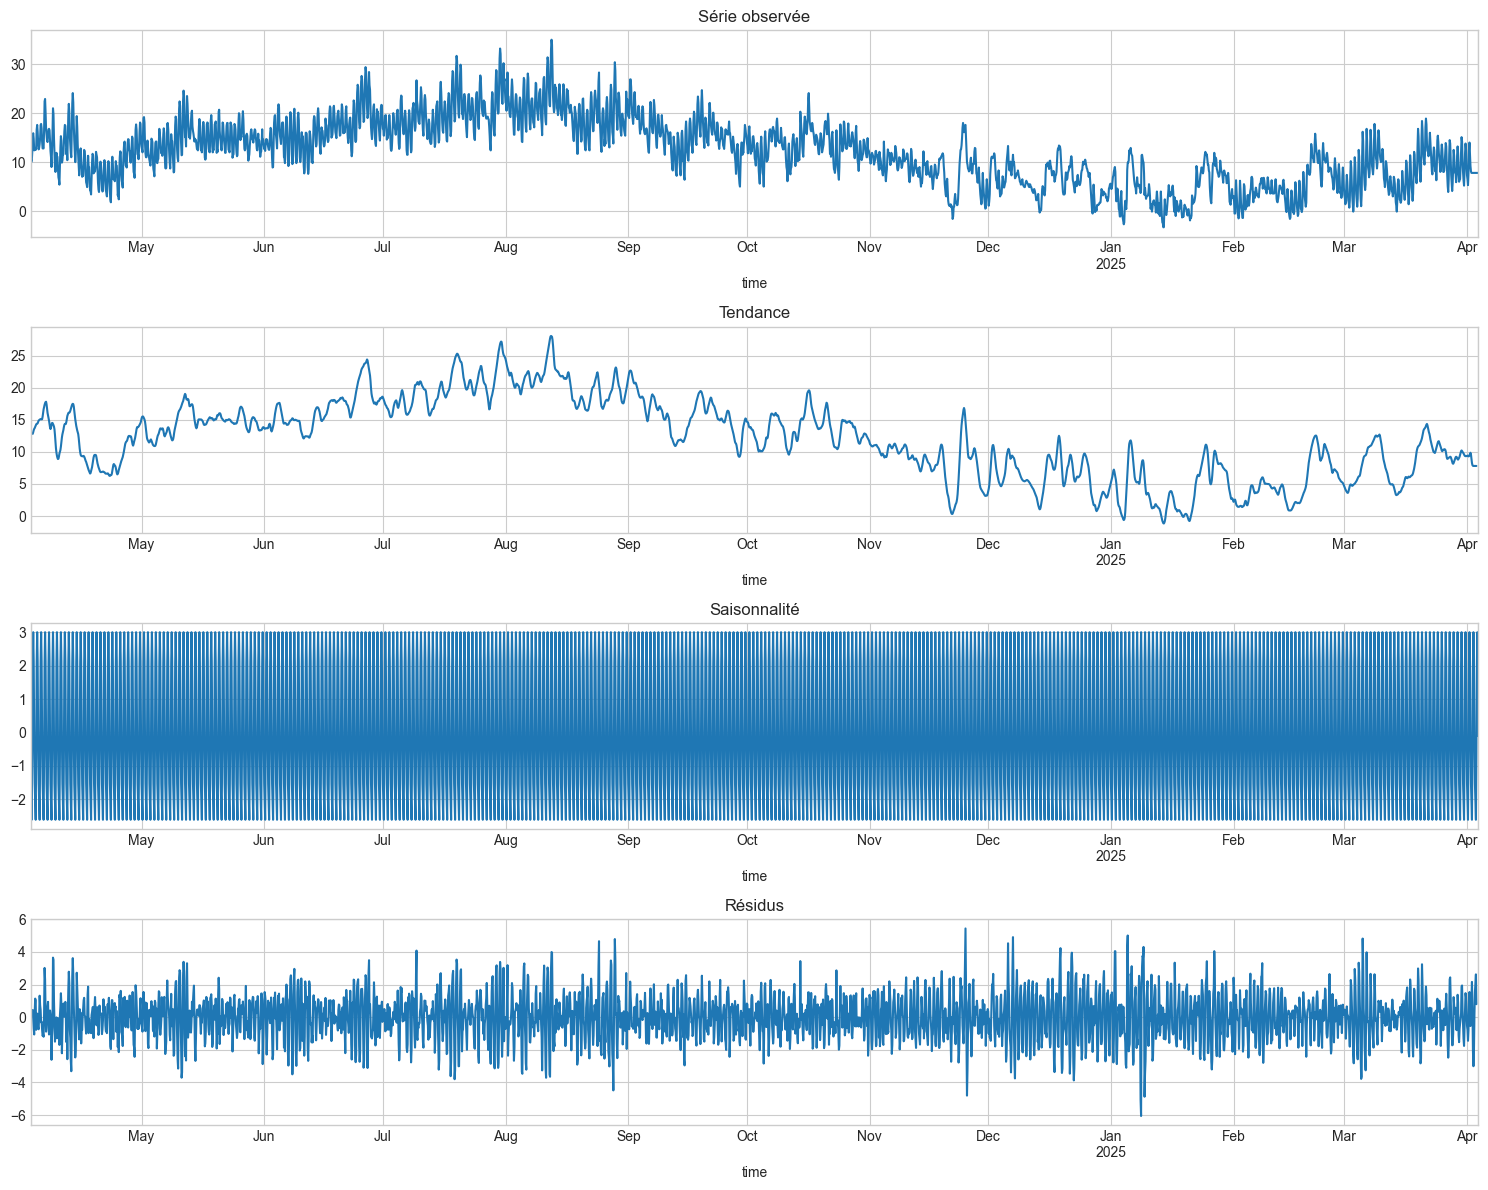

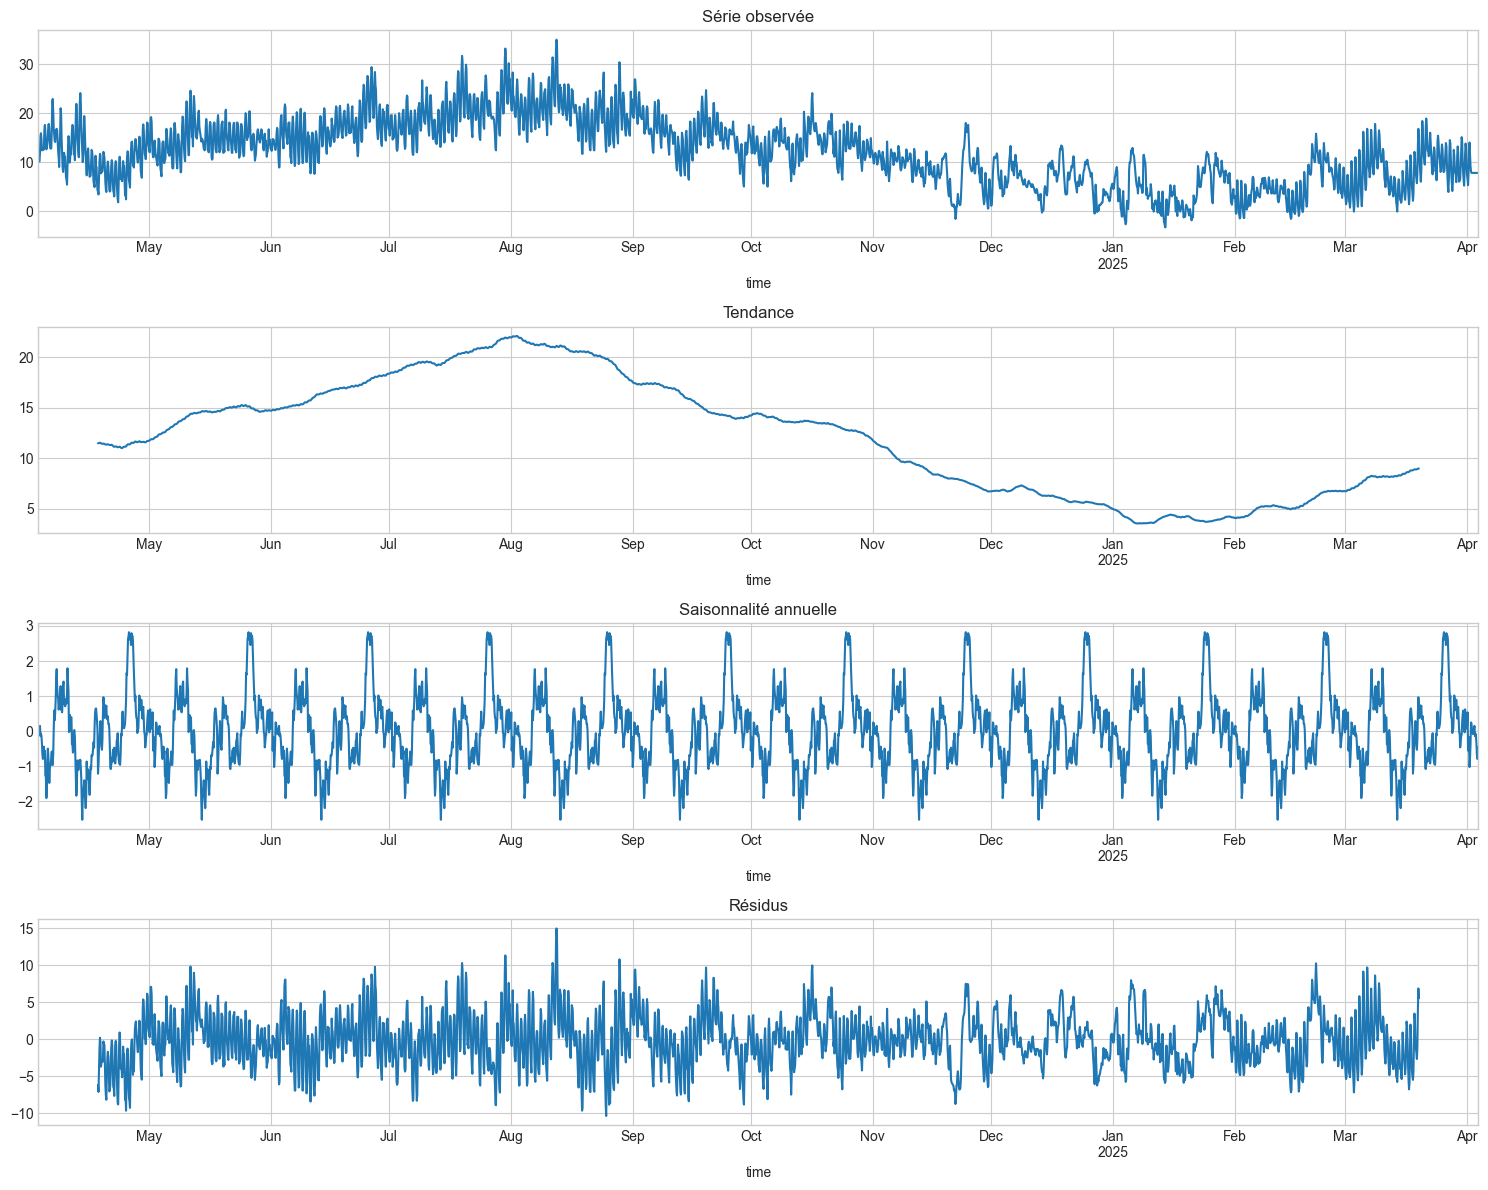

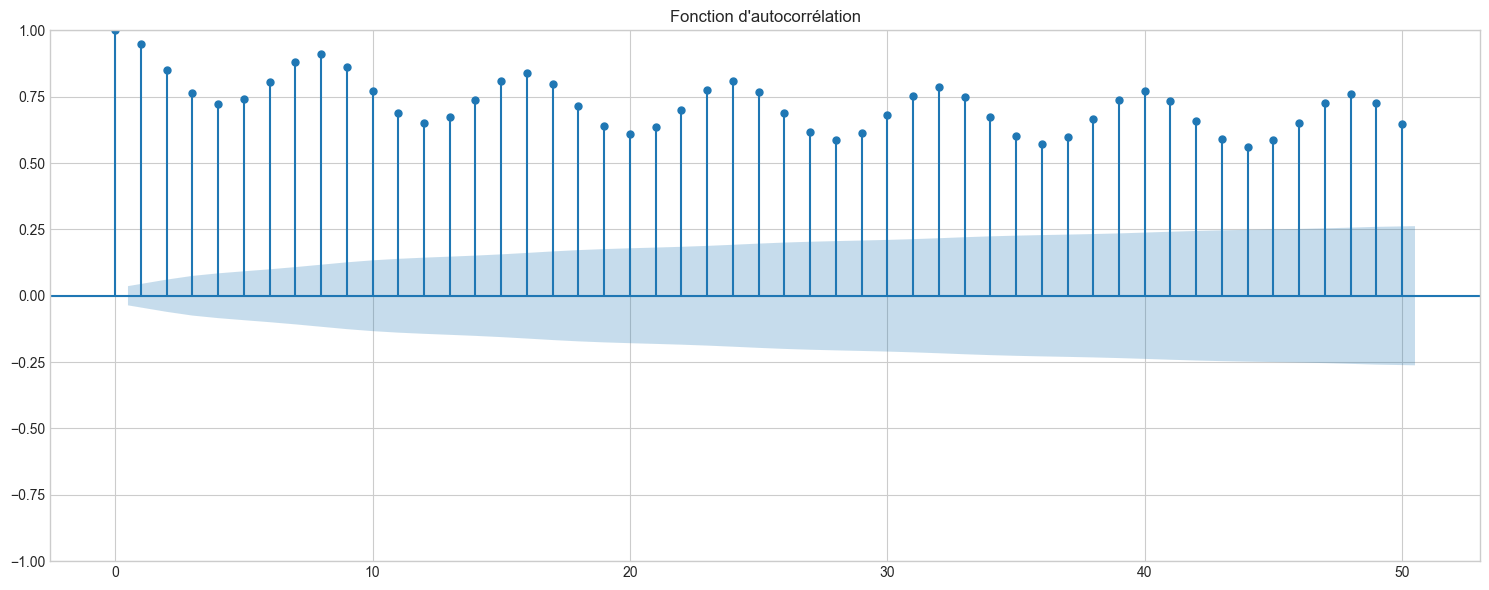

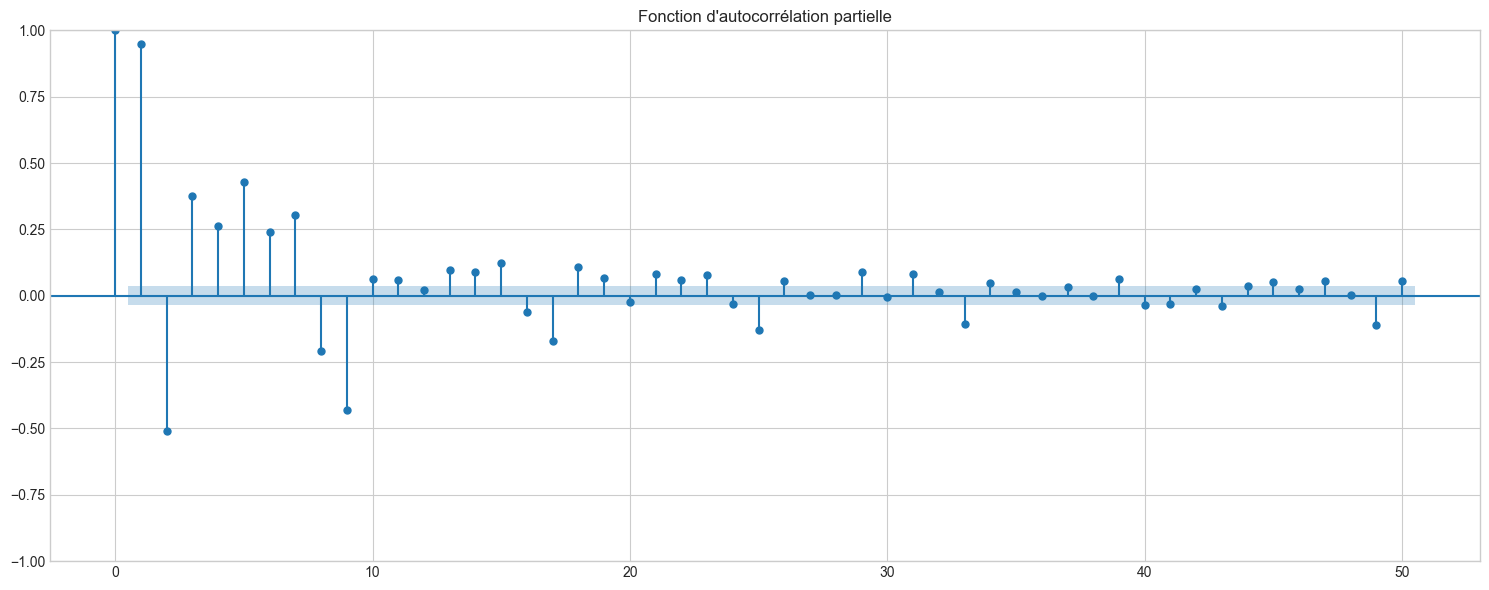

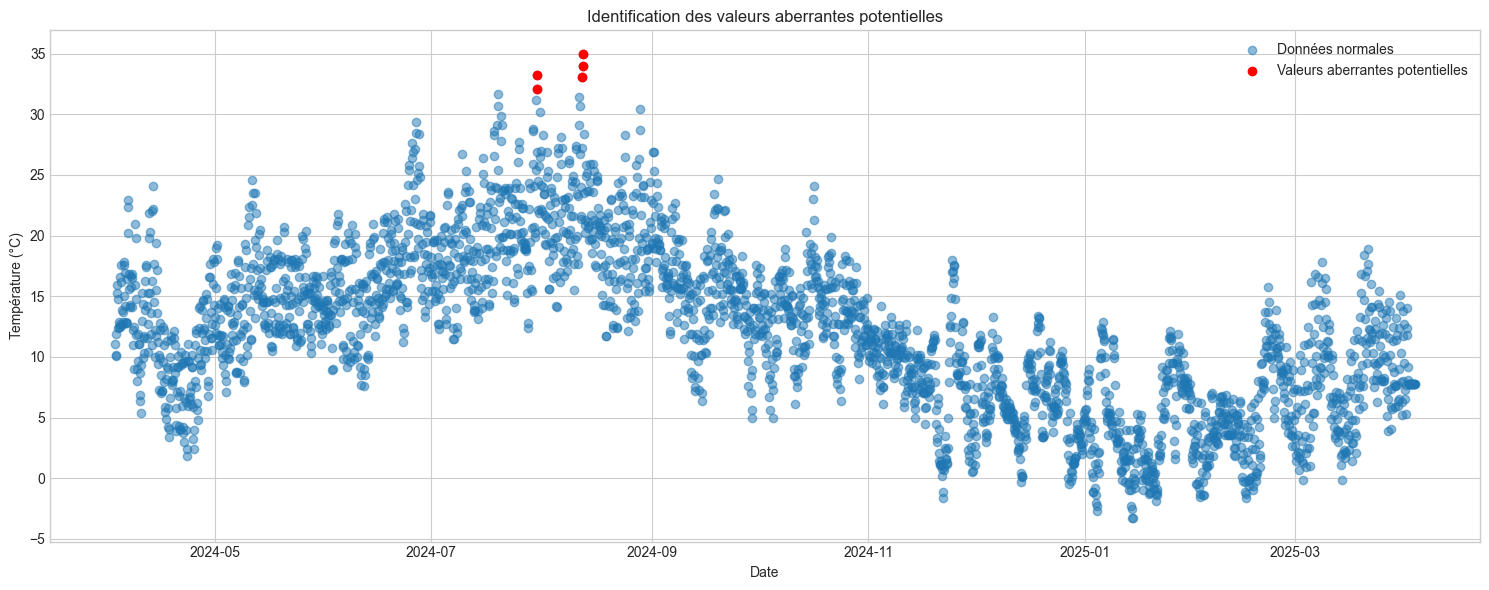

In [ ]:


# Chargement des données transformées
df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/weather_data_3h.csv")
df['time'] = pd.to_datetime(df['time'])
    
# Analyse exploratoire
exploratory_analysis(df)

In [22]:
# Importation des bibliothèques nécessaires pour tester la stationnarité
from statsmodels.tsa.stattools import adfuller, kpss


# cette fonction permet de verifier si la serie temporelle est stationnaire
def test_stationarity(timeseries, title=''):
    """
    Test de stationnarité d'une série temporelle
    - Test Augmented Dickey-Fuller (ADF): H0 = Non-stationnaire
    - Test KPSS: H0 = Stationnaire
    """
    print(f"Analyse de stationnarité pour {title}")
    
    # Visualisation de la série temporelle
    plt.figure(figsize=(12, 6))
    plt.plot(timeseries)
    plt.title(f'Série temporelle - {title}')
    plt.xlabel('Date')
    plt.ylabel('Valeur')
    plt.grid(True)
    plt.show()
    
    # Visualisation de la moyenne mobile et l'écart-type mobile
    rolling_mean = timeseries.rolling(window=8).mean()
    rolling_std = timeseries.rolling(window=8).std()
    
    plt.figure(figsize=(12, 6))
    plt.plot(timeseries, label='Original')
    plt.plot(rolling_mean, label='Moyenne mobile (8 périodes)')
    plt.plot(rolling_std, label='Écart-type mobile (8 périodes)')
    plt.title(f'Moyenne et écart-type mobiles - {title}')
    plt.xlabel('Date')
    plt.ylabel('Valeur')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Test Augmented Dickey-Fuller
    print('Test de stationnarité Augmented Dickey-Fuller (ADF):')
    result = adfuller(timeseries.dropna())
    
    print(f'Statistique ADF: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Valeurs critiques:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] < 0.05:
        print("=> La série est stationnaire (rejet de l'hypothèse nulle)")
    else:
        print("=> La série n'est pas stationnaire (acceptation de l'hypothèse nulle)")
    
    # Test KPSS
    print('\nTest de stationnarité KPSS:')
    try:
        result_kpss = kpss(timeseries.dropna())
        
        print(f'Statistique KPSS: {result_kpss[0]:.4f}')
        print(f'p-value: {result_kpss[1]:.4f}')
        print(f'Valeurs critiques:')
        for key, value in result_kpss[3].items():
            print(f'\t{key}: {value:.4f}')
        
        if result_kpss[1] < 0.05:
            print("=> La série n'est pas stationnaire (rejet de l'hypothèse nulle)")
        else:
            print("=> La série est stationnaire (acceptation de l'hypothèse nulle)")
    except:
        print("Erreur lors du test KPSS, probablement due à des valeurs manquantes ou problématiques")



Analyse de stationnarité pour Température à 2m


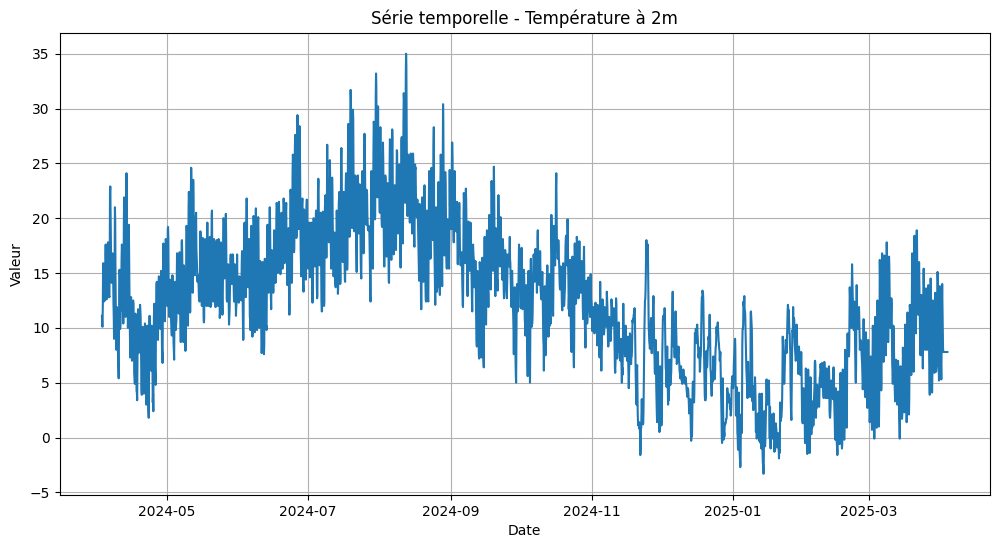

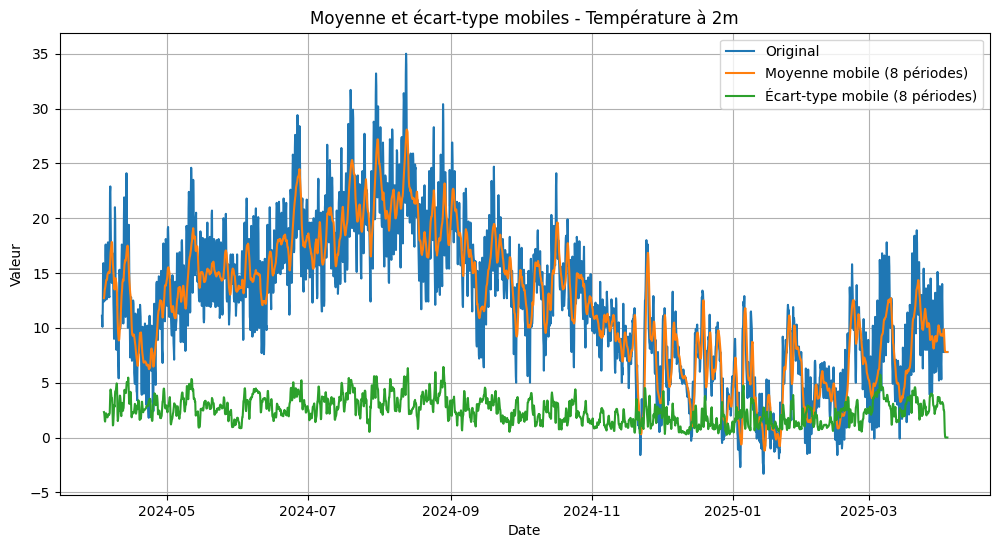

Test de stationnarité Augmented Dickey-Fuller (ADF):
Statistique ADF: -2.7106
p-value: 0.0722
Valeurs critiques:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
=> La série n'est pas stationnaire (acceptation de l'hypothèse nulle)

Test de stationnarité KPSS:
Statistique KPSS: 5.2467
p-value: 0.0100
Valeurs critiques:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
=> La série n'est pas stationnaire (rejet de l'hypothèse nulle)
Analyse de stationnarité pour Température à 2m - Première différenciation


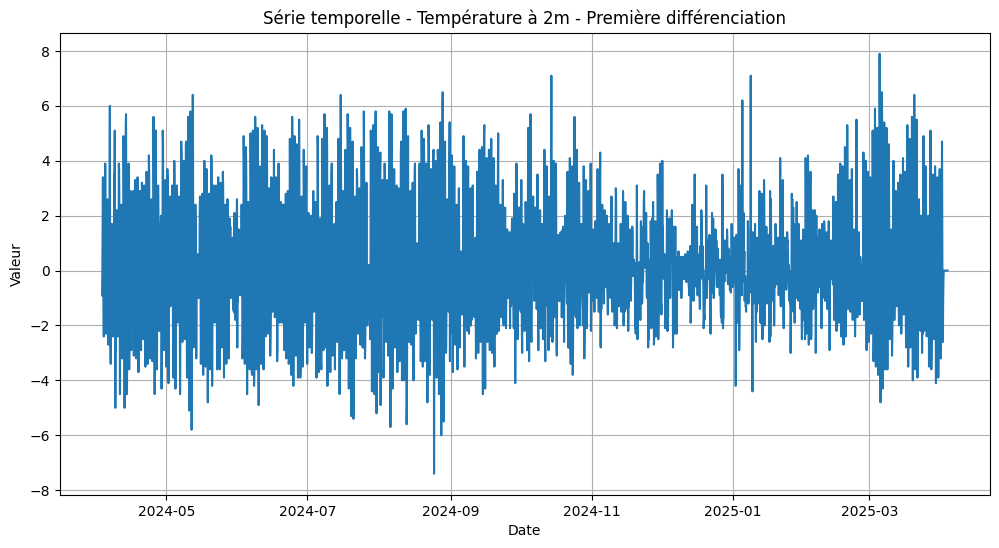

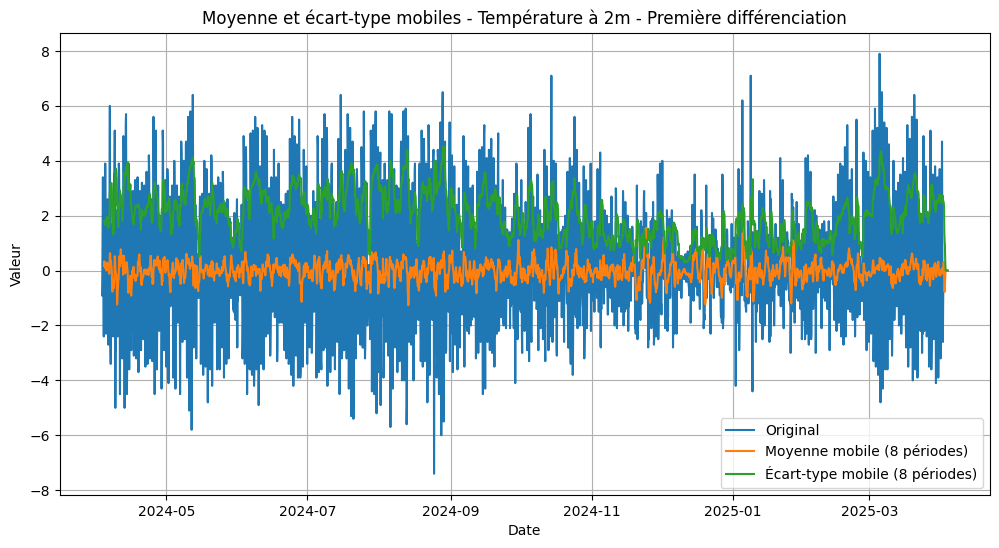

Test de stationnarité Augmented Dickey-Fuller (ADF):
Statistique ADF: -13.7478
p-value: 0.0000
Valeurs critiques:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
=> La série est stationnaire (rejet de l'hypothèse nulle)

Test de stationnarité KPSS:
Statistique KPSS: 0.0426
p-value: 0.1000
Valeurs critiques:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
=> La série est stationnaire (acceptation de l'hypothèse nulle)


In [23]:
# Application du test de stationnarité sur nos données
test_stationarity(df['temperature_2m'], 'Température à 2m')

# Si la série n'est pas stationnaire, nous devons la transformer
# Première différenciation (pour rendre la série stationnaire)
if not (adfuller(df['temperature_2m'].dropna())[1] < 0.05):
    df_diff = df['temperature_2m'].diff().dropna()
    test_stationarity(df_diff, 'Température à 2m - Première différenciation')
    
    # Si nécessaire, seconde différenciation
    if not (adfuller(df_diff.dropna())[1] < 0.05):
        df_diff2 = df_diff.diff().dropna()
        test_stationarity(df_diff2, 'Température à 2m - Seconde différenciation')

In [24]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [26]:
df.head()

,temperature_2m
time,
2024-04-03 00:00:00,11.1
2024-04-03 03:00:00,10.2
2024-04-03 06:00:00,10.1
2024-04-03 09:00:00,11.9
2024-04-03 12:00:00,15.3


In [8]:
# Conversion de la colonne 'time' en datetime
df['time'] = pd.to_datetime(df['time'])

# Définition de 'time' comme index
df = df.set_index('time')

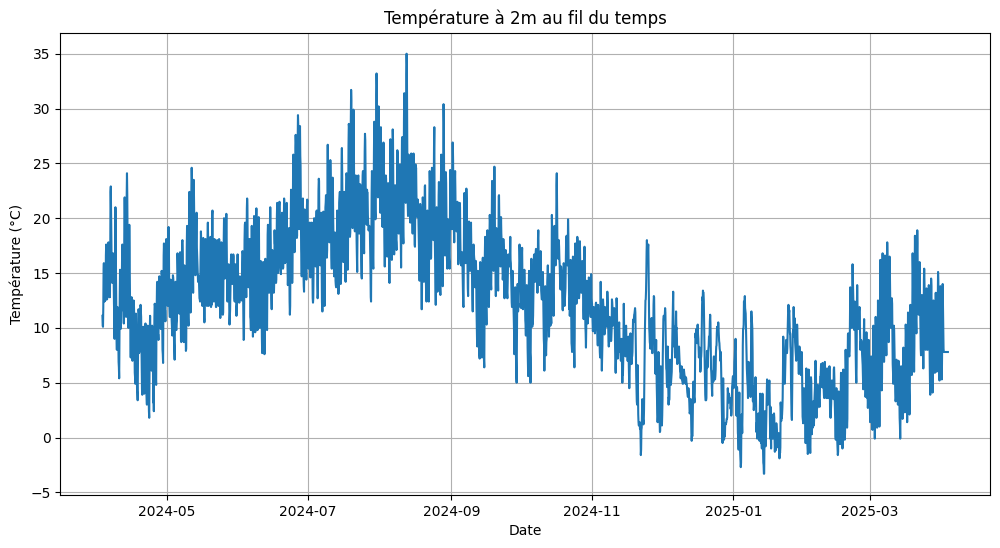

In [28]:
# Visualisation des données
plt.figure(figsize=(12, 6))
plt.plot(df['temperature_2m'])
plt.title('Température à 2m au fil du temps')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.grid(True)
plt.show()

In [11]:
# Diviser les données en ensembles d'entraînement et de test (80-20)
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

# Affichage des tailles des ensembles d'entraînement et de test

print(f"Taille de l'ensemble d'entraînement: {len(train)}")
print(f"Taille de l'ensemble de test: {len(test)}")

Taille de l'ensemble d'entraînement: 2342
Taille de l'ensemble de test: 586


In [20]:
train.shape, test.shape

((2342, 1), (586, 1))

In [21]:
train.head()

,temperature_2m
time,
2024-04-03 00:00:00,11.1
2024-04-03 03:00:00,10.2
2024-04-03 06:00:00,10.1
2024-04-03 09:00:00,11.9
2024-04-03 12:00:00,15.3


# Modèle ARIMA

In [29]:
# Définition de d=1 puisque la série est stationnaire après une différenciation
d_value = 1

# Utilisation d'auto_arima pour déterminer les paramètres optimaux
model_auto = auto_arima(train['temperature_2m'], d=d_value, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", trace=True)
print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7933.274, Time=19.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=10170.382, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9588.333, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9390.582, Time=2.62 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=10168.392, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=9080.508, Time=9.31 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=8589.459, Time=6.53 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=7929.897, Time=26.51 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=8488.492, Time=8.13 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=7811.117, Time=31.07 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=8249.809, Time=10.34 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=8250.840, Time=18.16 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=8152.743, Time=40.52 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=7932.412, Time=34.86 sec
 ARIMA(5,1,1)(0,0,0)[0] 

In [32]:
# Récupération des meilleurs paramètres p et q (d est fixé à 1)
best_p, _, best_q = model_auto.order

In [33]:
# Création et entraînement du modèle ARIMA
model_arima = ARIMA(train['temperature_2m'], order=(best_p, d_value, best_q))
arima_fit = model_arima.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         temperature_2m   No. Observations:                 2342
Model:                 ARIMA(4, 1, 2)   Log Likelihood               -3897.582
Date:                Fri, 04 Apr 2025   AIC                           7809.165
Time:                        06:48:59   BIC                           7849.473
Sample:                    04-03-2024   HQIC                          7823.848
                         - 01-20-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4448      0.020     73.881      0.000       1.406       1.483
ar.L2         -1.2815      0.033    -39.079      0.000      -1.346      -1.217
ar.L3          0.3690      0.034     10.848      0.0

In [34]:

# Prédictions sur l'ensemble de test
arima_pred = arima_fit.forecast(steps=len(test))

In [39]:
# Évaluation du modèle
arima_rmse = np.sqrt(mean_squared_error(test['temperature_2m'], arima_pred))
arima_mae = mean_absolute_error(test['temperature_2m'], arima_pred)
print(f"ARIMA RMSE: {arima_rmse:.4f}")
print(f"ARIMA MAE: {arima_mae:.4f}")

ARIMA RMSE: 8.4423
ARIMA MAE: 7.4563


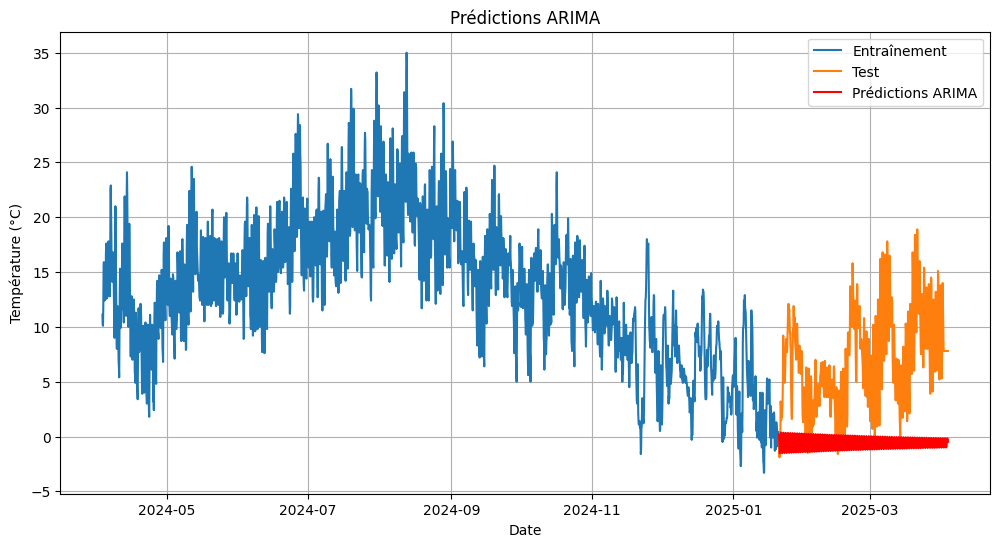

In [40]:
# Visualisation des prédictions
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['temperature_2m'], label='Entraînement')
plt.plot(test.index, test['temperature_2m'], label='Test')
plt.plot(test.index, arima_pred, label='Prédictions ARIMA', color='red')
plt.title('Prédictions ARIMA')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True)
plt.show()

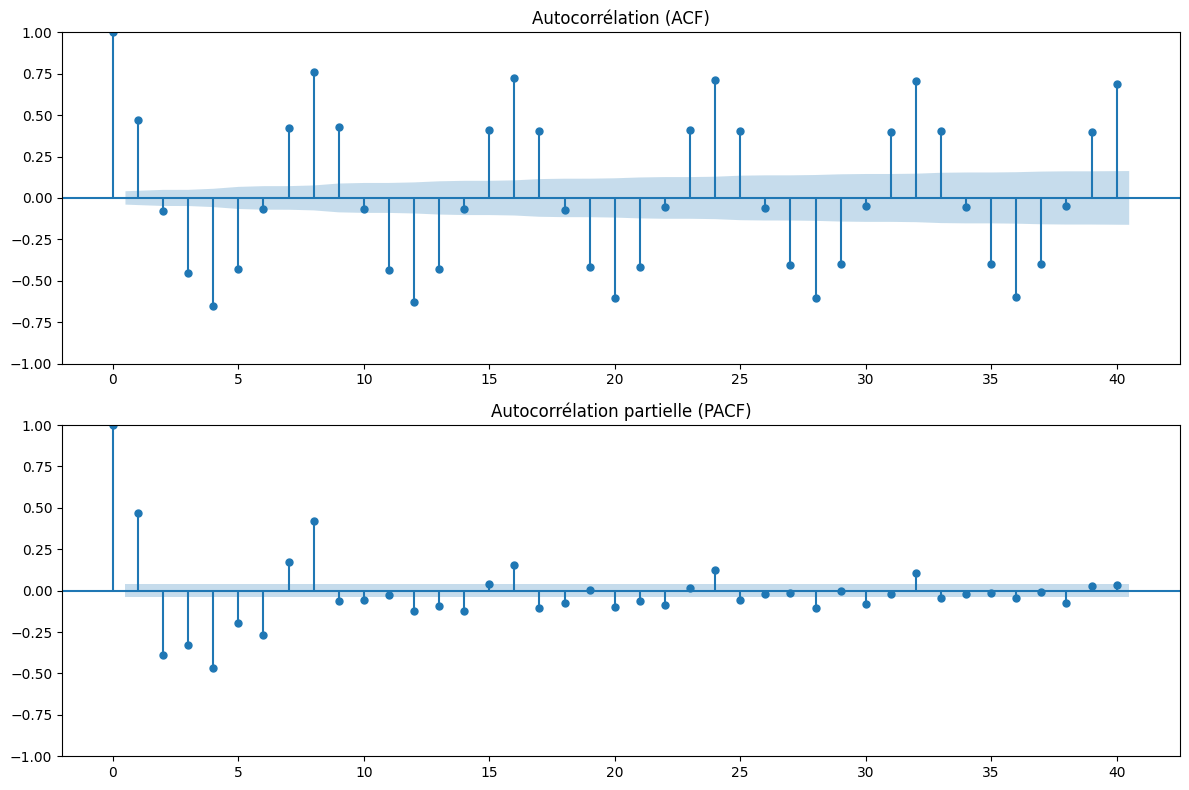

<Figure size 1200x1000 with 0 Axes>

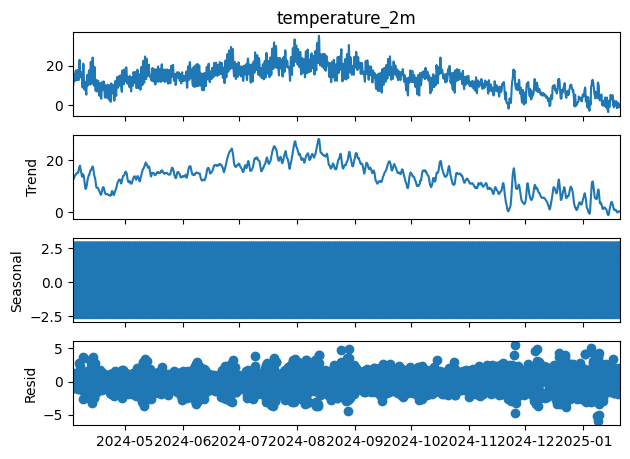

<Figure size 1200x1000 with 0 Axes>

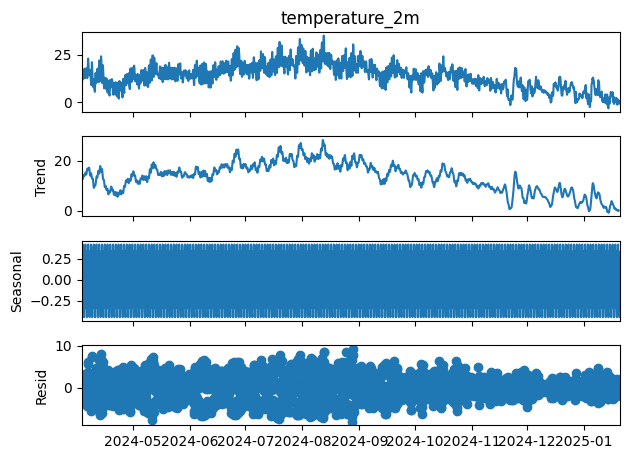

<Figure size 1200x1000 with 0 Axes>

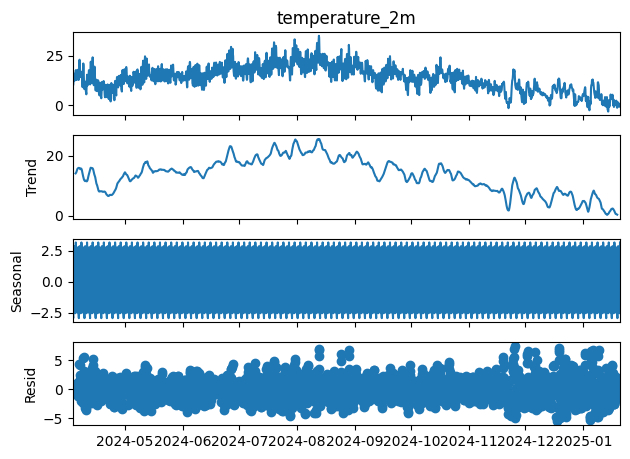

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Visualisation de l'ACF et PACF pour identifier les paramètres p, q, P, Q
plt.figure(figsize=(12, 8))
plt.subplot(211)
plot_acf(train['temperature_2m'].diff(d_value).dropna(), ax=plt.gca(), lags=40)
plt.title('Autocorrélation (ACF)')
plt.subplot(212)
plot_pacf(train['temperature_2m'].diff(d_value).dropna(), ax=plt.gca(), lags=40)
plt.title('Autocorrélation partielle (PACF)')
plt.tight_layout()
plt.show()

# Décomposition saisonnière pour détecter la période
from statsmodels.tsa.seasonal import seasonal_decompose

# Tester différentes périodes pour trouver la meilleure décomposition
for period in [8, 12, 24]:  # 8 pour données toutes les 3h, 24 pour données journalières
    try:
        decomposition = seasonal_decompose(train['temperature_2m'], model='additive', period=period)
        
        plt.figure(figsize=(12, 10))
        plt.suptitle(f'Décomposition saisonnière (période={period})')
        decomposition.plot()
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
    except:
        print(f"La décomposition avec période={period} n'a pas fonctionné")

#  Modèle SARIMA

In [49]:
seasonal_period = 56 # 56 périodes pour une saisonnalité de 7 jours (8 périodes par jour)

# Modèle SARIMA avec d=1 et paramètres saisonniers
model_auto_seasonal = auto_arima(train['temperature_2m'], 
    seasonal=True,
    m=seasonal_period,
    d=d_value,  # Fixer d=1
    D=1,        # Généralement 1 pour la différenciation saisonnière
    stepwise=True, 
    suppress_warnings=True, 
    error_action="ignore", 
    trace=True
)


print(model_auto_seasonal.summary())



Performing stepwise search to minimize aic


KeyboardInterrupt: 

In [47]:
# Récupération des meilleurs paramètres
best_p, _, best_q = model_auto_seasonal.order
best_P, best_D, best_Q, best_m = model_auto_seasonal.seasonal_order

# Création et entraînement du modèle SARIMA avec les paramètres optimaux
model_sarima = SARIMAX(train['temperature_2m'], 
    order=(best_p, d_value, best_q),
    seasonal_order=(best_P, best_D, best_Q, best_m)
)

sarima_fit = model_sarima.fit(disp=False)
print(sarima_fit.summary())

# Prédictions sur l'ensemble de test
sarima_pred = sarima_fit.forecast(steps=len(test))

                                     SARIMAX Results                                     
Dep. Variable:                    temperature_2m   No. Observations:                 2342
Model:             SARIMAX(4, 1, 0)x(2, 1, 0, 8)   Log Likelihood               -3788.491
Date:                           Fri, 04 Apr 2025   AIC                           7590.982
Time:                                   07:19:01   BIC                           7631.266
Sample:                               04-03-2024   HQIC                          7605.659
                                    - 01-20-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2203      0.018     12.311      0.000       0.185       0.255
ar.L2         -0.1065      0.020     -5.218

SARIMA RMSE: 35.7103
SARIMA MAE: 31.8360


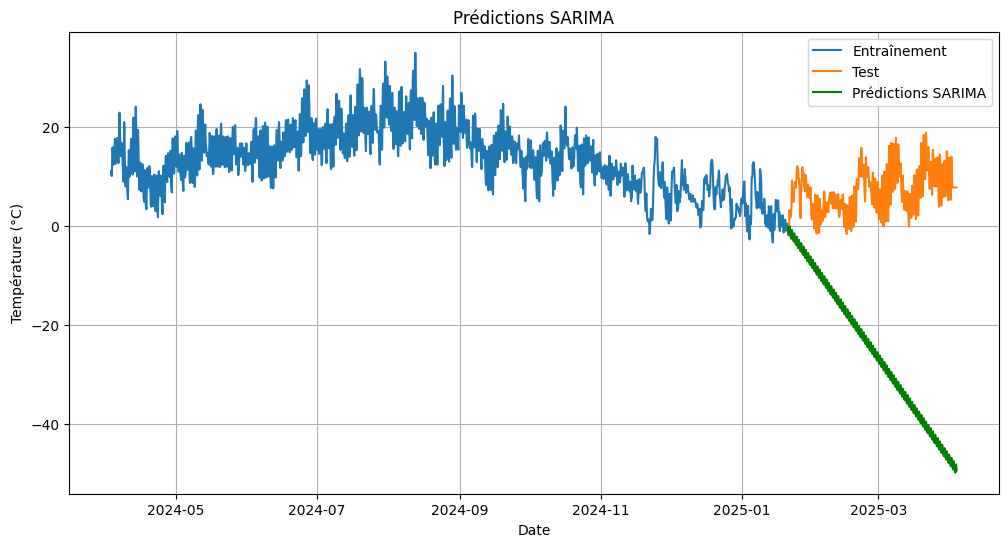

In [48]:

# Évaluation du modèle
sarima_rmse = np.sqrt(mean_squared_error(test['temperature_2m'], sarima_pred))
sarima_mae = mean_absolute_error(test['temperature_2m'], sarima_pred)
print(f"SARIMA RMSE: {sarima_rmse:.4f}")
print(f"SARIMA MAE: {sarima_mae:.4f}")

# Visualisation des prédictions
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['temperature_2m'], label='Entraînement')
plt.plot(test.index, test['temperature_2m'], label='Test')
plt.plot(test.index, sarima_pred, label='Prédictions SARIMA', color='green')
plt.title('Prédictions SARIMA')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
def get_historical_weather_data(latitude, longitude, start_date, end_date, variables=None):
    """
    Récupérer les données météorologiques historiques via l'API Open-Meteo
    
    Args:
        latitude (float): Latitude de la ville
        longitude (float): Longitude de la ville
        start_date (str): Date de début (format: YYYY-MM-DD)
        end_date (str): Date de fin (format: YYYY-MM-DD)
        variables (list, optional): Liste des variables météorologiques à récupérer.
                                   Par défaut: ["temperature_2m"]
    
    Returns:
        pandas.DataFrame: DataFrame contenant les données météorologiques demandées
    """
    import requests
    import pandas as pd
    
    # Définir les variables par défaut si non spécifiées
    if variables is None:
        variables = ["temperature_2m"]
    
    # Assurez-vous que variables est une liste
    if isinstance(variables, str):
        variables = [variables]
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    # Créer le paramètre hourly avec les variables demandées
    hourly_param = ",".join(variables)
    
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": hourly_param,
        "timezone": "auto"
    }
    
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        
        # Création du DataFrame avec la colonne temporelle
        df = pd.DataFrame({"time": data["hourly"]["time"]})
        
        # Ajout de chaque variable demandée comme colonne
        for var in variables:
            if var in data["hourly"]:
                df[var] = data["hourly"][var]
                
                # Vérification et traitement des valeurs manquantes
                if df[var].isna().sum() > 0:
                    print(f"Valeurs manquantes détectées dans {var}: {df[var].isna().sum()}")
                    # Interpolation linéaire pour les valeurs manquantes
                    df[var] = df[var].interpolate(method="linear")
            else:
                print(f"Variable '{var}' non disponible dans les données")
        
        # Conversion de la colonne time en datetime
        df["time"] = pd.to_datetime(df["time"])
        
        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        print(response.text)
        return None

In [53]:
# Exemple d'utilisation pour récupérer température et humidité

end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

df = get_historical_weather_data(
    latitude=48.8566,  # Paris
    longitude=2.3522,
    start_date=start_date,
    end_date=end_date,
    variables=["temperature_2m", "relativehumidity_2m"]
)

Valeurs manquantes détectées dans temperature_2m: 45
Valeurs manquantes détectées dans relativehumidity_2m: 45


In [55]:
if df is not None:
    print(f"Données récupérées: {len(df)} entrées")
    print(df.head())
        
# Sauvegarde des données brutes
    df.to_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/raw_weather_data_exogene.csv", index=False)

Données récupérées: 8784 entrées
                 time  temperature_2m  relativehumidity_2m
0 2024-04-04 00:00:00            12.5                 84.0
1 2024-04-04 01:00:00            12.4                 85.0
2 2024-04-04 02:00:00            12.5                 84.0
3 2024-04-04 03:00:00            12.8                 89.0
4 2024-04-04 04:00:00            12.8                 88.0


In [56]:
import pandas as pd
from datetime import datetime

def transform_to_3h_interval(df):
    """
    Transformer les données horaires en données avec un pas de temps de 3 heures
    
    Args:
        df (pandas.DataFrame): DataFrame avec données horaires
        
    Returns:
        pandas.DataFrame: DataFrame avec données agrégées par tranches de 3 heures
    """
    # Copie du DataFrame
    df_copy = df.copy()
    
    # Création d'une colonne pour grouper par tranches de 3 heures
    df_copy['hour'] = df_copy['time'].dt.hour
    df_copy['group_3h'] = (df_copy['hour'] // 3) * 3
    
    # Création d'une colonne de date sans l'heure
    df_copy['date'] = df_copy['time'].dt.date
    
    # Identification des colonnes de données (à l'exception des colonnes de temps et de regroupement)
    data_columns = [col for col in df_copy.columns if col not in ['time', 'hour', 'group_3h', 'date']]
    
    # Création d'un nouveau DataFrame pour stocker les résultats
    result = []
    
    # Pour chaque jour et chaque groupe de 3 heures
    for date, date_group in df_copy.groupby('date'):
        for group_3h, hour_group in date_group.groupby('group_3h'):
            # Création d'un dictionnaire pour stocker le timestamp et les valeurs moyennes
            entry = {
                'time': datetime.combine(date, datetime.min.time()) + pd.Timedelta(hours=group_3h)
            }
            
            # Calcul de la moyenne pour chaque colonne de données
            for col in data_columns:
                entry[col] = round(hour_group[col].mean(), 1)
            
            result.append(entry)
    
    # Création du DataFrame final
    df_3h = pd.DataFrame(result)
    
    # Tri par date/heure
    df_3h = df_3h.sort_values('time')
    
    return df_3h

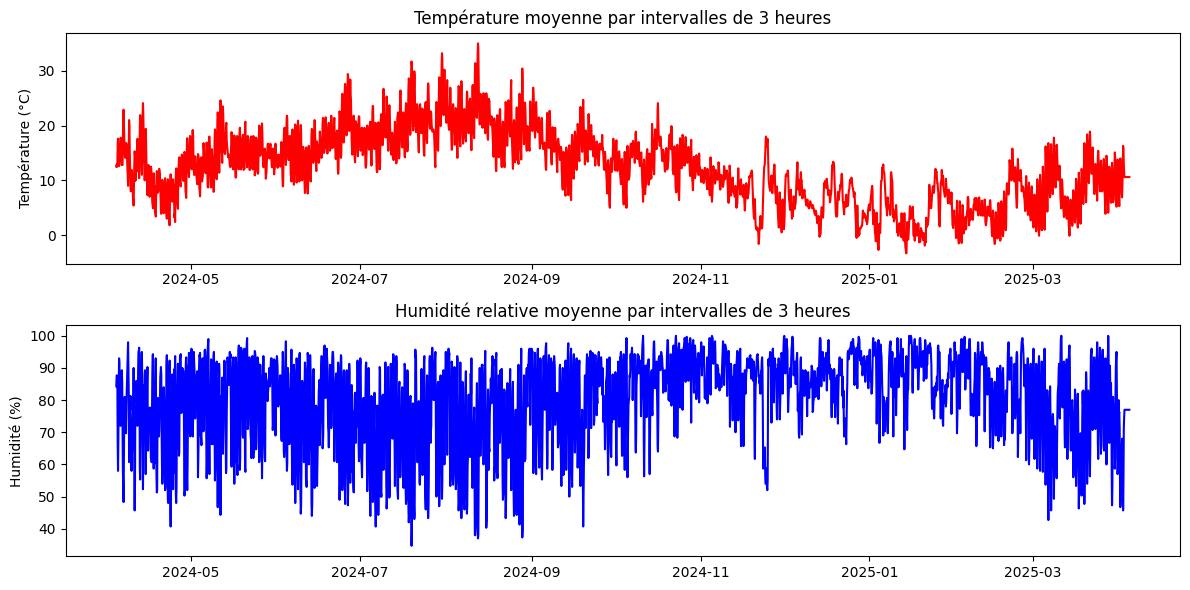

In [57]:

df_3h = transform_to_3h_interval(df)

# Visualisation des données
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(df_3h['time'], df_3h['temperature_2m'], 'r-')
plt.title('Température moyenne par intervalles de 3 heures')
plt.ylabel('Température (°C)')

plt.subplot(212)
plt.plot(df_3h['time'], df_3h['relativehumidity_2m'], 'b-')
plt.title('Humidité relative moyenne par intervalles de 3 heures')
plt.ylabel('Humidité (%)')

plt.tight_layout()
plt.show()

In [59]:
 # Sauvegarde des données transformées
df_3h.to_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/weather_data_3h_exogene.csv", index=False)

# SARIMAX

In [61]:
data = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/weather_data_3h_exogene.csv")
data['time'] = pd.to_datetime(data['time'])
data = data.set_index('time')
# Séparation des données en ensembles d'entraînement et de test (80-20)
train_size = int(len(data) * 0.8)
train = data[:train_size]
test = data[train_size:]
# Affichage des tailles des ensembles d'entraînement et de test
print(f"Taille de l'ensemble d'entraînement: {len(train)}")
print(f"Taille de l'ensemble de test: {len(test)}")

Taille de l'ensemble d'entraînement: 2342
Taille de l'ensemble de test: 586


In [62]:
data.head()

,temperature_2m,relativehumidity_2m
time,,
2024-04-04 00:00:00,12.5,84.3
2024-04-04 03:00:00,12.9,87.7
2024-04-04 06:00:00,12.5,87.7
2024-04-04 09:00:00,12.7,87.0
2024-04-04 12:00:00,16.6,66.3


In [63]:


# Définition de d=1 puisque la série est stationnaire après une différenciation
d_value = 1 

# Préparation des variables exogènes
exog_train = train[['relativehumidity_2m']].values
exog_test = test[['relativehumidity_2m']].values 

# Modèle SARIMAX avec les paramètres optimaux et variables exogènes
model_sarimax = SARIMAX(train['temperature_2m'],
    exog=exog_train,
    order=(best_p, d_value, best_q),
    seasonal_order=(best_P, best_D, best_Q, best_m)
)

sarimax_fit = model_sarimax.fit(disp=False)
print(sarimax_fit.summary())

# Prédictions sur l'ensemble de test
sarimax_pred = sarimax_fit.forecast(steps=len(test), exog=exog_test)

                                     SARIMAX Results                                     
Dep. Variable:                    temperature_2m   No. Observations:                 2342
Model:             SARIMAX(4, 1, 0)x(2, 1, 0, 8)   Log Likelihood               -3263.998
Date:                           Fri, 04 Apr 2025   AIC                           6543.997
Time:                                   10:42:31   BIC                           6590.036
Sample:                               04-04-2024   HQIC                          6560.770
                                    - 01-21-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.1226      0.003    -46.794      0.000      -0.128      -0.117
ar.L1          0.3492      0.017     20.671

In [65]:
# Évaluez les performances
mse = mean_squared_error(test['temperature_2m'], sarimax_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 19.92704926474882


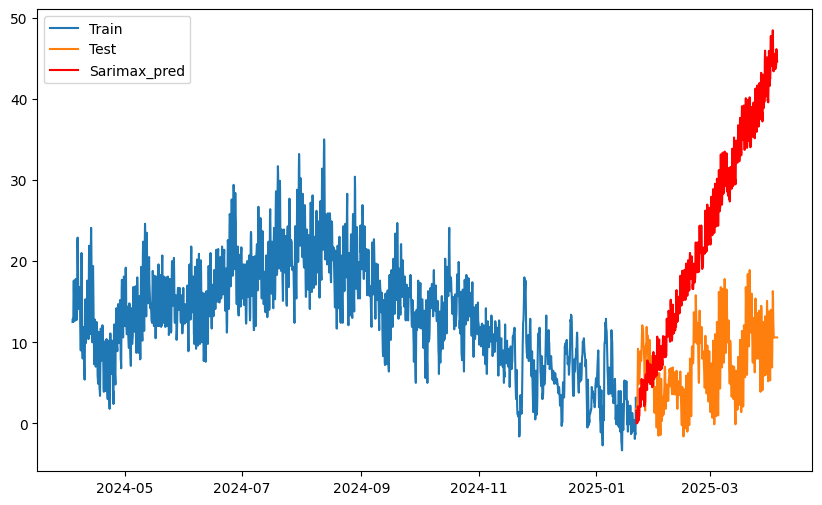

In [67]:
# Visualisez les résultats
plt.figure(figsize=(10, 6))
plt.plot(train['temperature_2m'], label='Train')
plt.plot(test['temperature_2m'], label='Test')
plt.plot(test.index, sarimax_pred, label='Sarimax_pred', color='red')
plt.legend()
plt.show()

# Expérimentation avec des méthodes de régression basées sur le Machine Learning

In [68]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

In [93]:
# Création de variables retardées (lag)
for lag in range(1, 9):  
    data[f'temp_lag_{lag}'] = data['temperature_2m'].shift(lag)
    data[f'humidity_lag_{lag}'] = data['relativehumidity_2m'].shift(lag)

# Création de variables agrégées (moyennes mobiles)
for window in [3, 6, 12]:  # Fenêtres de 3, 6 et 12 heures
    data[f'temp_rolling_mean_{window}'] = data['temperature_2m'].rolling(window=window).mean()
    data[f'humidity_rolling_mean_{window}'] = data['relativehumidity_2m'].rolling(window=window).mean()

# Variables cycliques pour capturer les effets saisonniers
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month

# Transformation des variables cycliques en coordonnées circulaires
data['hour_sin'] = np.sin(2 * np.pi * data['hour']/24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour']/24)
data['day_sin'] = np.sin(2 * np.pi * data['day_of_week']/7)
data['day_cos'] = np.cos(2 * np.pi * data['day_of_week']/7)
data['month_sin'] = np.sin(2 * np.pi * data['month']/12)
data['month_cos'] = np.cos(2 * np.pi * data['month']/12)

# Supprimer les lignes avec des valeurs NaN (créées par les décalages)

data.dropna(inplace=True)


In [94]:
data.head()

,temperature_2m,relativehumidity_2m,temp_lag_1,humidity_lag_1,temp_lag_2,humidity_lag_2,temp_lag_3,humidity_lag_3,temp_lag_4,humidity_lag_4,...,humidity_rolling_mean_12,hour,day_of_week,month,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
time,,,,,,,,,,,,,,,,,,,,,
2024-04-10 12:00:00,13.0,56.3,9.3,79.3,5.4,90.0,6.4,84.0,6.9,73.7,...,71.800000,12,2,4,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.866025,-0.5
2024-04-10 15:00:00,15.3,45.7,13.0,56.3,9.3,79.3,5.4,90.0,6.4,84.0,...,68.833333,15,2,4,-7.071068e-01,-7.071068e-01,0.974928,-0.222521,0.866025,-0.5
2024-04-10 18:00:00,14.4,54.7,15.3,45.7,13.0,56.3,9.3,79.3,5.4,90.0,...,67.166667,18,2,4,-1.000000e+00,-1.836970e-16,0.974928,-0.222521,0.866025,-0.5
2024-04-10 21:00:00,9.9,77.7,14.4,54.7,15.3,45.7,13.0,56.3,9.3,79.3,...,68.058333,21,2,4,-7.071068e-01,7.071068e-01,0.974928,-0.222521,0.866025,-0.5
2024-04-11 00:00:00,10.3,73.0,9.9,77.7,14.4,54.7,15.3,45.7,13.0,56.3,...,69.308333,0,3,4,0.000000e+00,1.000000e+00,0.433884,-0.900969,0.866025,-0.5


In [98]:
'''
Test de différentes configurations de variables explicatives
Maintenant, créons différentes configurations de variables explicatives pour tester nos modèles 
'''

# Définir la variable cible (target)
target = 'temperature_2m'  # ou 'relativehumidity_2m'

# Configuration 1: Variables de base
config1 = ['relativehumidity_2m']  # Si target est temperature_2m

# Configuration 2: Variables de base + variables retardées
config2 = config1 + [f'temp_lag_{i}' for i in range(1, 4)] + [f'humidity_lag_{i}' for i in range(1, 4)]

# Configuration 3: Variables de base + variables retardées + moyennes mobiles
config3 = config2 + [f'temp_rolling_mean_{i}' for i in [3, 6, 12]] + [f'humidity_rolling_mean_{i}' for i in [3, 6, 12]]

# Configuration 4: Toutes les variables y compris variables cycliques
config4 = config3 + ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']

# Liste des configurations
configs = [config1, config2, config3, config4]
config_names = ['Base', 'Base+Lag', 'Base+Lag+Rolling', 'All Features']

In [99]:
''''
Comparaison de plusieurs modèles de régression
Comparons maintenant différents modèles de régression pour chaque configuration :
'''

# Définir les modèles à tester
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Pour stocker les résultats
results = pd.DataFrame(columns=['Model', 'Configuration', 'MAE', 'RMSE', 'R²'])

# Diviser les données en ensembles d'entraînement (80%) et de test (20%)
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Évaluer chaque modèle avec chaque configuration
for config_idx, config in enumerate(configs):
    X_train = train_data[config]
    y_train = train_data[target]
    X_test = test_data[config]
    y_test = test_data[target]
    
    # Standardiser les features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for name, model in models.items():
        # Entraîner le modèle
        model.fit(X_train_scaled, y_train)
        
        # Faire des prédictions
        y_pred = model.predict(X_test_scaled)
        
        # Calculer les métriques
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # Enregistrer les résultats
        results = pd.concat([results, pd.DataFrame({
            'Model': [name],
            'Configuration': [config_names[config_idx]],
            'MAE': [mae],
            'RMSE': [rmse],
            'R²': [r2]
        })])



               Model     Configuration           MAE          RMSE        R²
0  Linear Regression  Base+Lag+Rolling  1.242443e-14  1.520029e-14  1.000000
0  Linear Regression      All Features  1.389017e-14  1.692743e-14  1.000000
0              Ridge      All Features  1.436918e-01  1.822277e-01  0.998089
0              Ridge  Base+Lag+Rolling  1.446878e-01  1.824532e-01  0.998084
0      Random Forest      All Features  6.540208e-01  8.640033e-01  0.957038
0      Random Forest  Base+Lag+Rolling  6.619965e-01  8.831976e-01  0.955108
0              Lasso      All Features  7.452687e-01  9.297485e-01  0.950251
0  Gradient Boosting      All Features  7.545950e-01  9.637835e-01  0.946542
0  Linear Regression          Base+Lag  7.495807e-01  9.826417e-01  0.944429
0              Ridge          Base+Lag  7.562137e-01  9.896194e-01  0.943637
0              Lasso  Base+Lag+Rolling  7.950293e-01  1.000478e+00  0.942394
0  Gradient Boosting  Base+Lag+Rolling  8.077976e-01  1.028055e+00  0.939174

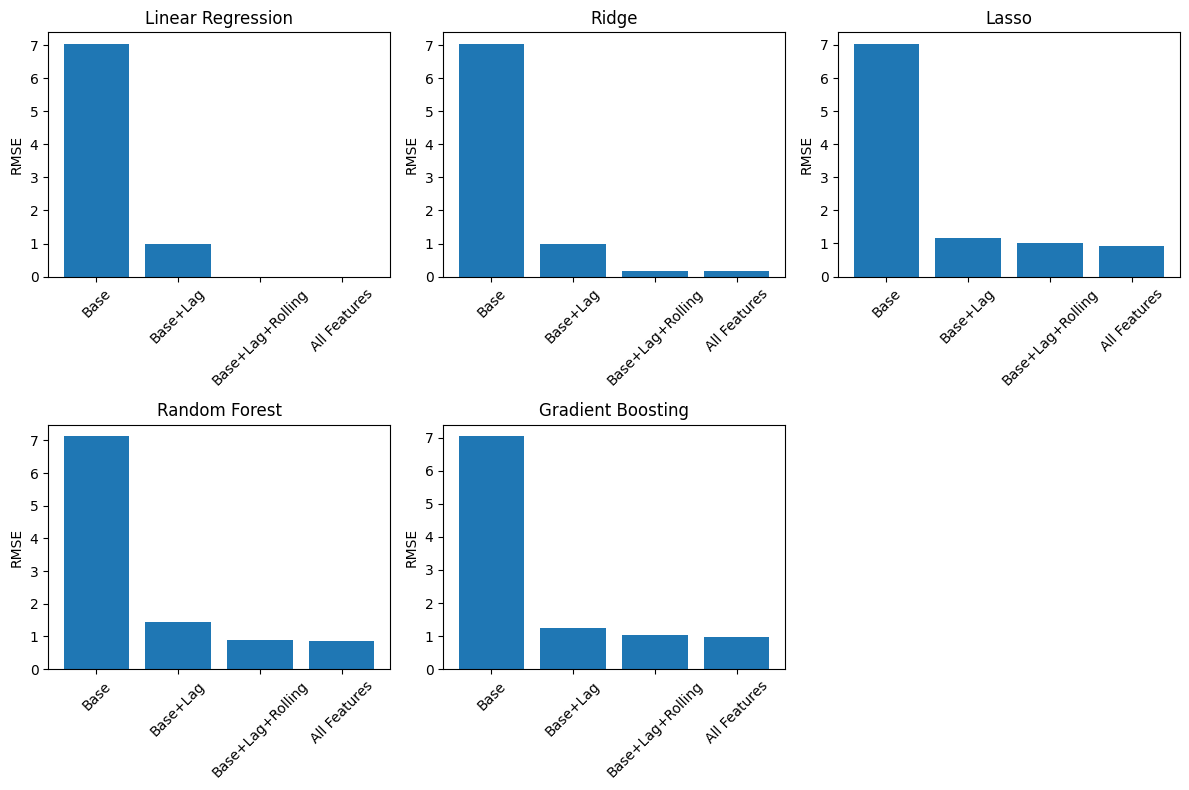

In [100]:
# Afficher les résultats
print(results.sort_values(by='RMSE'))

# Visualiser les résultats
plt.figure(figsize=(12, 8))
for i, model_name in enumerate(models.keys()):
    model_results = results[results['Model'] == model_name]
    plt.subplot(2, 3, i+1)
    plt.bar(model_results['Configuration'], model_results['RMSE'])
    plt.title(model_name)
    plt.xticks(rotation=45)
    plt.ylabel('RMSE')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

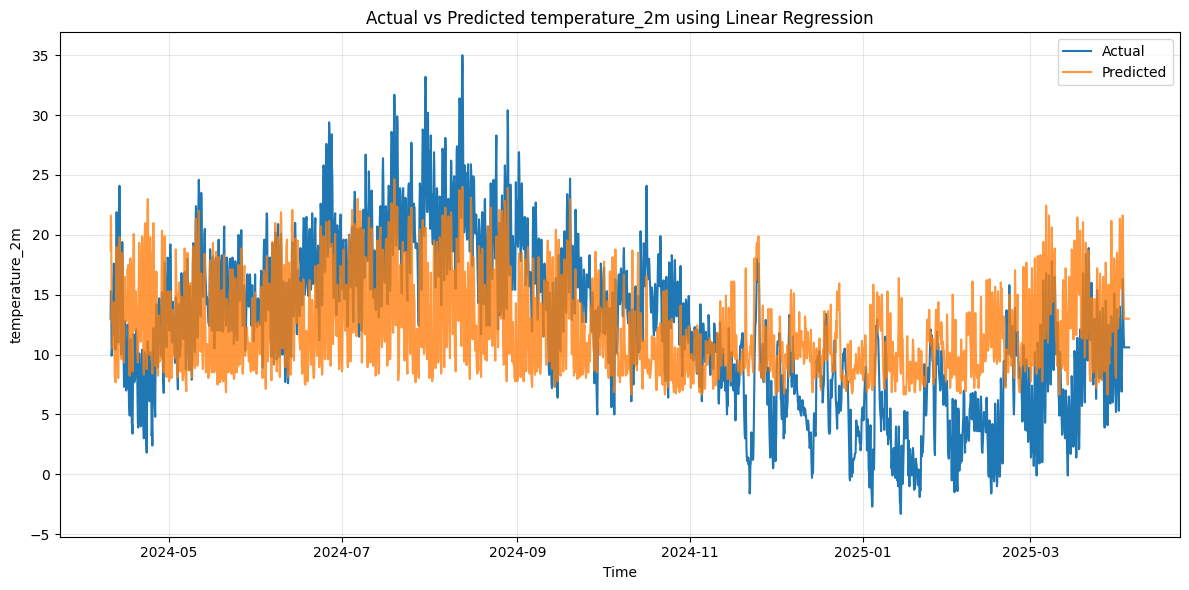

Performance du meilleur modèle (Linear Regression) avec Base:
MAE: 4.5920
RMSE: 5.4971
R²: 0.3162


In [104]:
# Trouver le meilleur modèle et sa configuration
best_idx = results['RMSE'].idxmin()
best_row = results.loc[best_idx]

# Extraire les valeurs individuelles (non pas des Series)
best_model_name = best_row['Model']
if isinstance(best_model_name, pd.Series):
    best_model_name = best_model_name.iloc[0]

best_config_name = best_row['Configuration']
if isinstance(best_config_name, pd.Series):
    best_config_name = best_config_name.iloc[0]

# Maintenant utiliser la valeur unique pour trouver l'index
best_config_idx = config_names.index(best_config_name)
best_config = configs[best_config_idx]

# Préparation des données pour le meilleur modèle
X = data[best_config]
y = data[target]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Réentraîner le meilleur modèle
best_model = models[best_model_name]
best_model.fit(X_scaled, y)

# Faire des prédictions
y_pred = best_model.predict(X_scaled)

# Analyser l'importance des variables pour les modèles compatibles
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    # Extraction et visualisation des importances
    importances = best_model.feature_importances_
    feature_imp = pd.DataFrame({
        'Feature': best_config, 
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_imp['Feature'], feature_imp['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance for {best_model_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

# Visualiser les prédictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, y, label='Actual', linewidth=1.5)
plt.plot(data.index, y_pred, label='Predicted', linewidth=1.5, alpha=0.8)
plt.title(f'Actual vs Predicted {target} using {best_model_name}')
plt.xlabel('Time')
plt.ylabel(target)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions.png')
plt.show()

# Afficher les métriques de performance
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
print(f'Performance du meilleur modèle ({best_model_name}) avec {best_config_name}:')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')

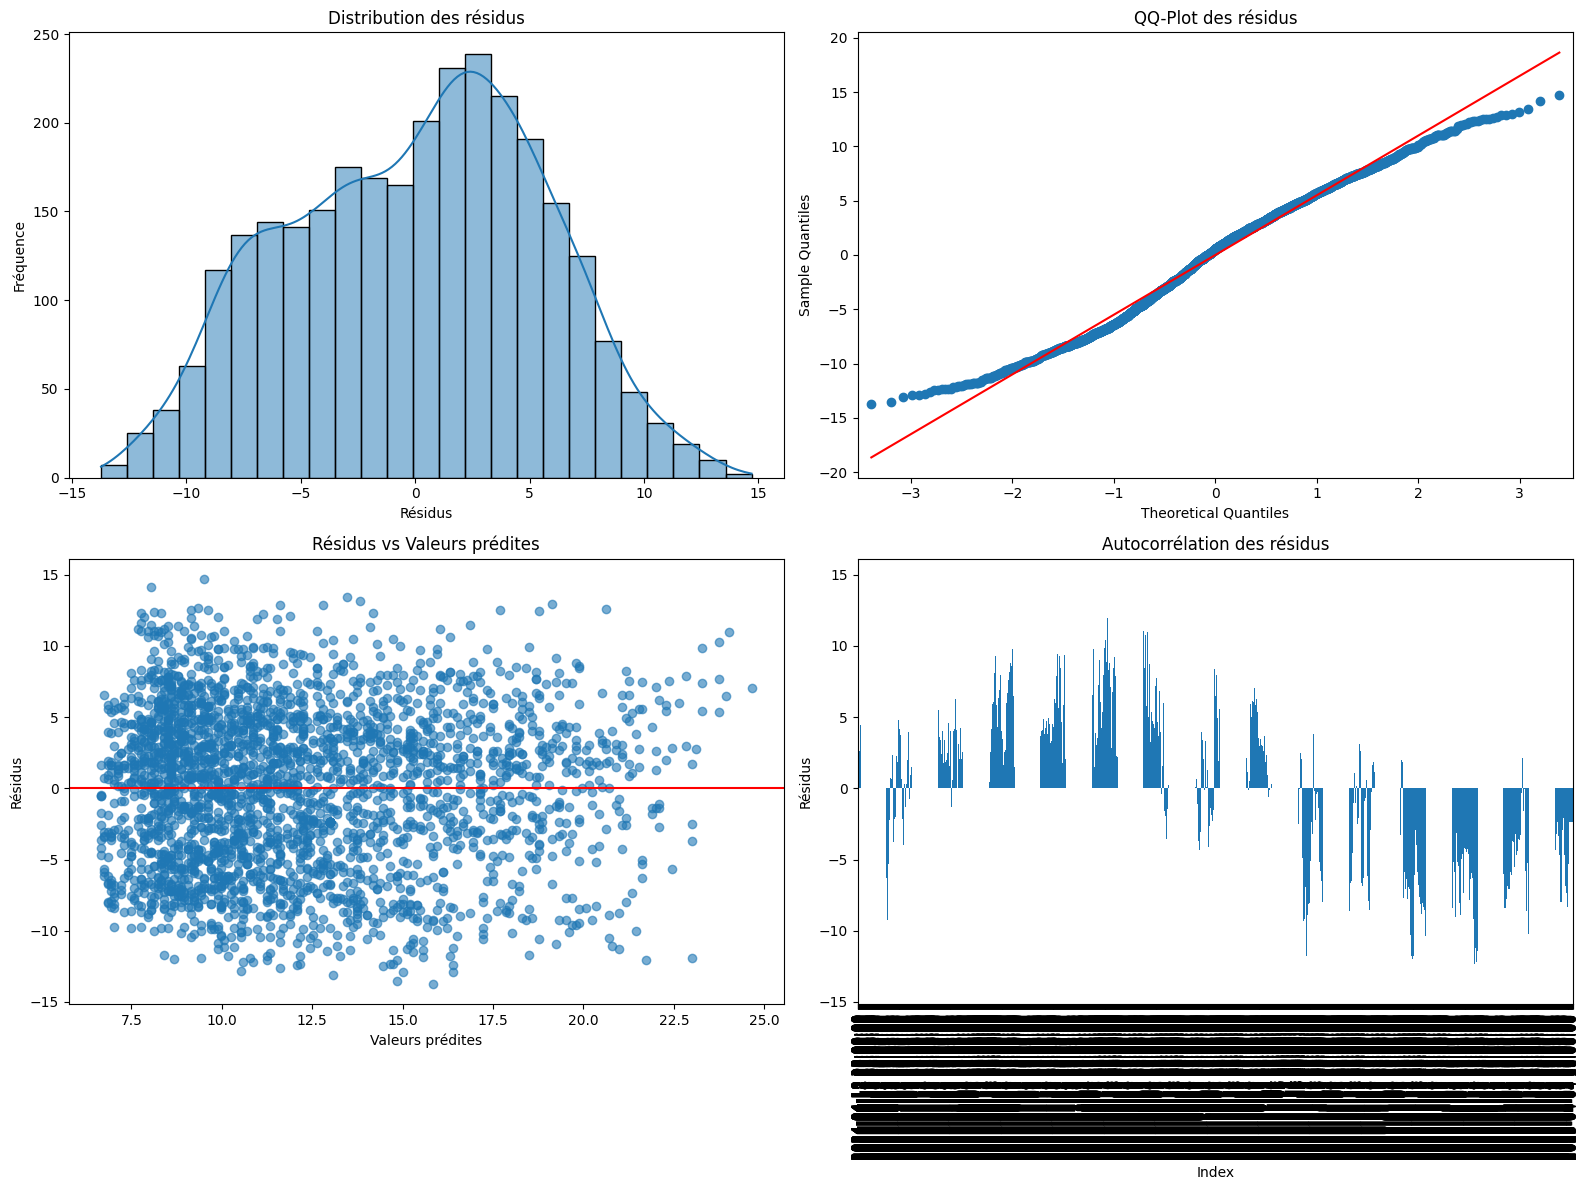

Test de Shapiro-Wilk pour la normalité des résidus:
Statistique du test: 0.9872
p-value: 0.0000
Les résidus ne suivent pas une distribution normale (p < 0.05)


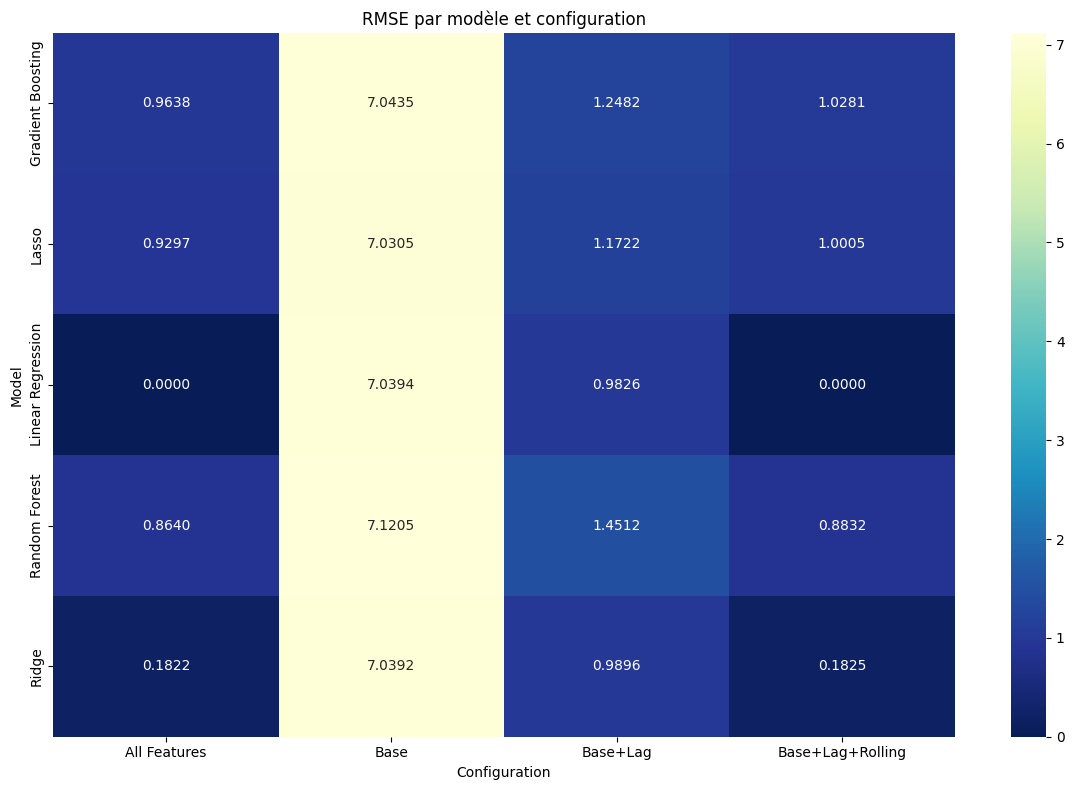

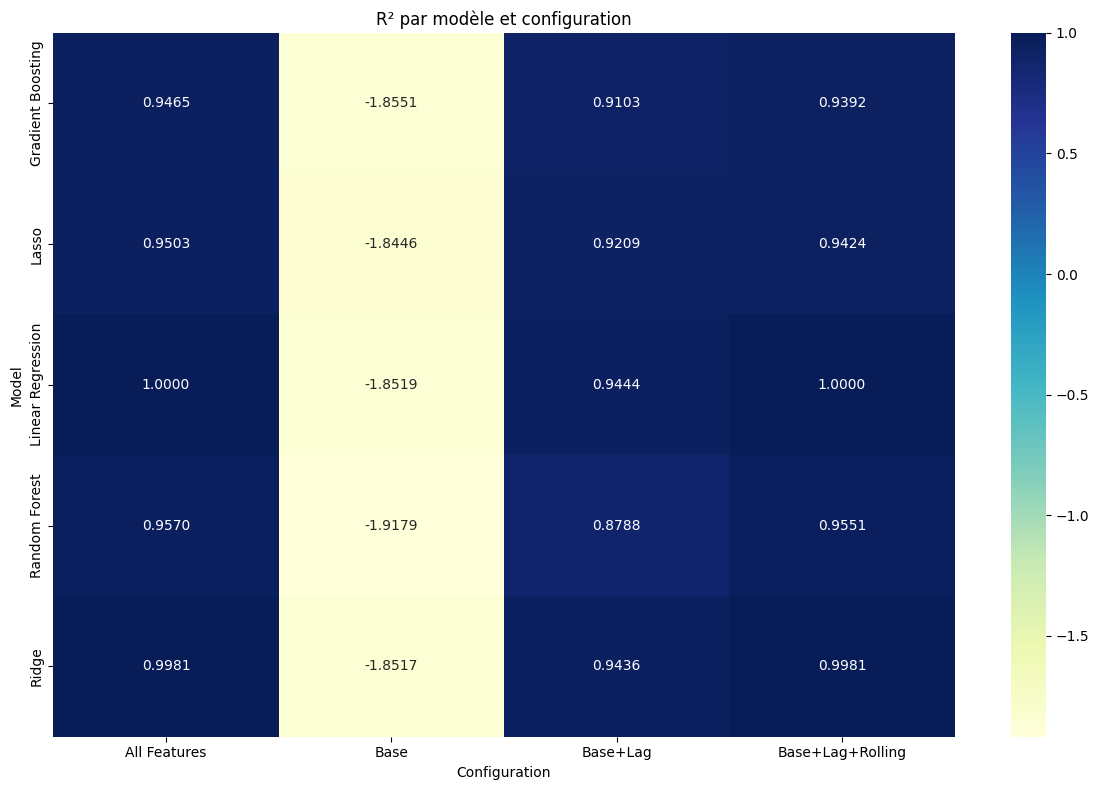


Métriques additionnelles pour le meilleur modèle:
MAPE: 7442018014204205.00%
Erreur moyenne: 0.0000
Erreur médiane: 0.5725
Durbin-Watson: 0.0514 (2 = pas d'autocorrélation, <2 = autocorrélation positive, >2 = autocorrélation négative)

Performance par quartile:
             Actual        Predicted  Residual           Abs_Error
               mean count       mean      mean       std      mean
Quartile                                                          
Q1         3.628710   721  10.239877 -6.611167  2.630356  6.611167
Q2         9.753857   726  10.924364 -1.170508  3.263904  2.579522
Q3        14.416318   717  11.860014  2.556304  3.377934  3.692547
Q4        20.734831   712  15.420828  5.314003  3.504665  5.505126


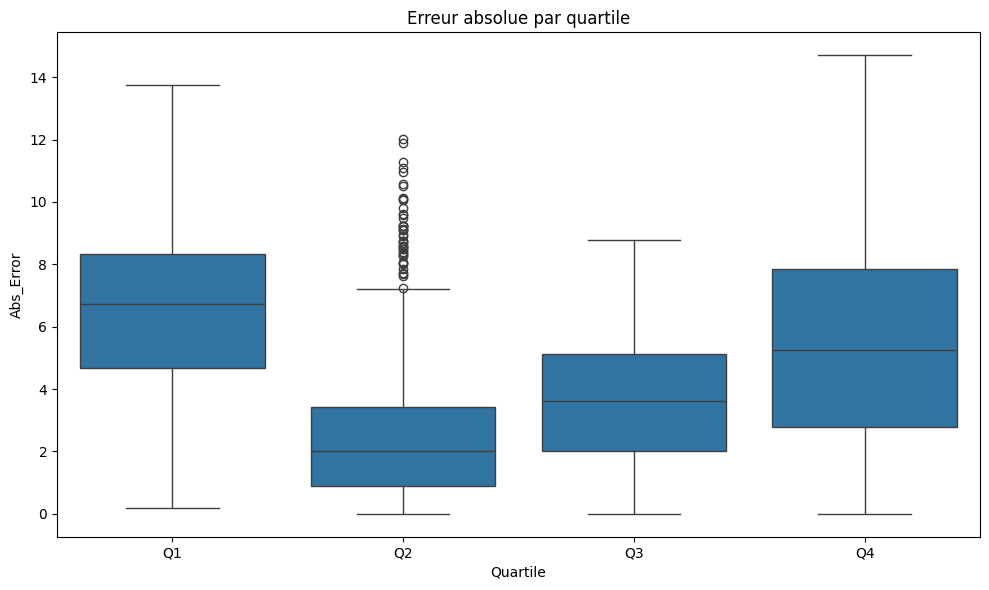


Résumé des résultats:
1. Le meilleur modèle est Linear Regression avec la configuration Base
2. RMSE: 5.4971, R²: 0.3162, MAPE: 7442018014204205.00%
3. Les résidus ne suivent pas une distribution normale, ce qui pourrait indiquer que le modèle ne capture pas tous les patterns.
4. Le test de Durbin-Watson (0.05) indique une autocorrélation positive des résidus, suggérant que le modèle pourrait manquer des patterns temporels.

Recommandations pour améliorer le modèle:
1. Exploration de variables explicatives supplémentaires
2. Optimisation des hyperparamètres via GridSearchCV ou RandomizedSearchCV
3. Test d'autres algorithmes comme XGBoost ou des réseaux de neurones


In [105]:
# Analyse des résidus et évaluation des performances
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import seaborn as sns

# Calcul des résidus pour le meilleur modèle
residuals = y - y_pred

# 1. Distribution des erreurs résiduelles
plt.figure(figsize=(16, 12))

# Histogramme des résidus
plt.subplot(2, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Distribution des résidus')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')

# QQ-plot pour vérifier la normalité des résidus
plt.subplot(2, 2, 2)
qqplot(residuals, line='s', ax=plt.gca())
plt.title('QQ-Plot des résidus')

# Résidus vs valeurs prédites
plt.subplot(2, 2, 3)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Résidus vs Valeurs prédites')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')

# Autocorrélation des résidus
plt.subplot(2, 2, 4)
pd.Series(residuals).plot(kind='bar', ax=plt.gca())
plt.title('Autocorrélation des résidus')
plt.xlabel('Index')
plt.ylabel('Résidus')

plt.tight_layout()
plt.savefig('residuals_analysis.png')
plt.show()

# Test de normalité des résidus (Test de Shapiro-Wilk)
shapiro_test = stats.shapiro(residuals)
print(f"Test de Shapiro-Wilk pour la normalité des résidus:")
print(f"Statistique du test: {shapiro_test[0]:.4f}")
print(f"p-value: {shapiro_test[1]:.4f}")
if shapiro_test[1] < 0.05:
    print("Les résidus ne suivent pas une distribution normale (p < 0.05)")
else:
    print("Les résidus suivent une distribution normale (p > 0.05)")

# 2. Comparaison des performances des modèles
# Réorganiser les résultats pour faciliter la visualisation
pivot_rmse = results.pivot(index='Model', columns='Configuration', values='RMSE')
pivot_r2 = results.pivot(index='Model', columns='Configuration', values='R²')

# Visualisation des performances (RMSE) par modèle et configuration
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_rmse, annot=True, cmap='YlGnBu_r', fmt='.4f')
plt.title('RMSE par modèle et configuration')
plt.tight_layout()
plt.savefig('model_comparison_rmse.png')
plt.show()

# Visualisation des performances (R²) par modèle et configuration
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_r2, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('R² par modèle et configuration')
plt.tight_layout()
plt.savefig('model_comparison_r2.png')
plt.show()

# 3. Métriques additionnelles pour le meilleur modèle
# Calculer MAPE (Mean Absolute Percentage Error)
mape = mean_absolute_percentage_error(y, y_pred) * 100

# Calculer l'erreur moyenne et l'erreur médiane
mean_error = np.mean(residuals)
median_error = np.median(residuals)

# Calculer le score de Durbin-Watson pour l'autocorrélation
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuals)

print("\nMétriques additionnelles pour le meilleur modèle:")
print(f"MAPE: {mape:.2f}%")
print(f"Erreur moyenne: {mean_error:.4f}")
print(f"Erreur médiane: {median_error:.4f}")
print(f"Durbin-Watson: {dw_stat:.4f} (2 = pas d'autocorrélation, <2 = autocorrélation positive, >2 = autocorrélation négative)")

# 4. Documentation et interprétation des résultats

# Mesurer la performance du modèle par plage de valeurs (ex: efficacité par quartile)
quartiles = pd.qcut(y, 4, labels=["Q1", "Q2", "Q3", "Q4"])
performance_by_quartile = pd.DataFrame({
    'Quartile': quartiles,
    'Actual': y,
    'Predicted': y_pred,
    'Residual': residuals,
    'Abs_Error': np.abs(residuals)
})

quartile_performance = performance_by_quartile.groupby('Quartile').agg({
    'Actual': ['mean', 'count'],
    'Predicted': 'mean',
    'Residual': ['mean', 'std'],
    'Abs_Error': 'mean'
})

print("\nPerformance par quartile:")
print(quartile_performance)

# Visualisation des performances par quartile
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quartile', y='Abs_Error', data=performance_by_quartile)
plt.title('Erreur absolue par quartile')
plt.tight_layout()
plt.savefig('performance_by_quartile.png')
plt.show()

# Résumé des résultats
print("\nRésumé des résultats:")
print(f"1. Le meilleur modèle est {best_model_name} avec la configuration {best_config_name}")
print(f"2. RMSE: {rmse:.4f}, R²: {r2:.4f}, MAPE: {mape:.2f}%")

if shapiro_test[1] < 0.05:
    print("3. Les résidus ne suivent pas une distribution normale, ce qui pourrait indiquer que le modèle ne capture pas tous les patterns.")
else:
    print("3. Les résidus suivent une distribution normale, ce qui est bon signe pour le modèle.")

if dw_stat < 1.5:
    print(f"4. Le test de Durbin-Watson ({dw_stat:.2f}) indique une autocorrélation positive des résidus, suggérant que le modèle pourrait manquer des patterns temporels.")
elif dw_stat > 2.5:
    print(f"4. Le test de Durbin-Watson ({dw_stat:.2f}) indique une autocorrélation négative des résidus.")
else:
    print(f"4. Le test de Durbin-Watson ({dw_stat:.2f}) indique une absence d'autocorrélation significative des résidus.")

# Recommandations pour améliorer le modèle
print("\nRecommandations pour améliorer le modèle:")
print("1. Exploration de variables explicatives supplémentaires")
print("2. Optimisation des hyperparamètres via GridSearchCV ou RandomizedSearchCV")
print("3. Test d'autres algorithmes comme XGBoost ou des réseaux de neurones")

In [110]:
#Enregistrement du best modèle
import pickle
# Enregistrer le modèle
with open('C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/model/registry/linear_regression.pkl', 'wb') as f:
    pickle.dump(best_model, f)